## §0. Imports and workspace setup

In [1]:
import os, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# ------------------------------------------------------------
#  Paths — resolved relative to the repository root.
#  Adjust BASE_DIR if you have placed CAISO data outside the repo.
# ------------------------------------------------------------
BASE_DIR  = Path.cwd()                     # repository root (run notebook from there)
DATA_DIR  = BASE_DIR / "data"
CAISO_CSV = DATA_DIR / "CAISO_2025_15min_LMP.csv"

FIG_DIR   = BASE_DIR / "figures"
RES_DIR   = BASE_DIR / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Make source modules importable
sys.path.insert(0, str(BASE_DIR))

# ------------------------------------------------------------
#  Module imports
# ------------------------------------------------------------
from baseline_model import (
    ElectricityMarketABM, ModelParameters, ScenarioConfig,
    SCENARIOS_6CELL, default_params, run_self_tests,
)
from analysis import (
    # Existing (v0.2)
    run_mechanism_decomposition, plot_decomposition,
    run_cross_scenario_decomposition,
    compare_clearing_rules,
    run_p3_stress,
    run_acquisition_sensitivity, acquisition_sensitivity_summary,
    run_compute_concentration_sweep, compute_sweep_summary, plot_compute_sweep,
    run_agent_count_sensitivity, agent_count_summary, plot_agent_count_sensitivity,
    run_compute_share_sweep, compute_share_sweep_summary, plot_compute_share_sweep,
    # NEW (v0.3) — counterfactual policy simulations
    run_counterfactual_breakup,
    run_counterfactual_ppa_disclosure,
    run_counterfactual_cost_disclosure,
    run_counterfactual_lockup_indicator,
    counterfactual_summary, plot_counterfactuals,
)
from caiso_validation import (
    caiso_summary_stats, load_caiso_lmp,
    validate_against_caiso, plot_caiso_validation,
)

# Verify CAISO data is reachable. Reviewers who have not yet downloaded the
# CAISO 2025 day-ahead LMP file (SCE DLAP, see README "Data" section for the
# OASIS download protocol) will see a notice here; CAISO validation cells will
# skip gracefully without aborting the notebook.
if CAISO_CSV.exists():
    print(f"\u2713 Workspace ready. CAISO data: {CAISO_CSV.stat().st_size / 1024**2:.1f} MB")
else:
    print(f"\u26a0 CAISO data not found at {CAISO_CSV}")
    print(f"  Please download from http://oasis.caiso.com (see README \"Data\" section).")
    print(f"  CAISO validation cells will skip without this file.")
print(f"  Results will be saved to: {RES_DIR}")
print(f"  Figures will be saved to: {FIG_DIR}")

# ------------------------------------------------------------
#  Verify baseline_model.py is v6 (scale-revised)
# ------------------------------------------------------------
# Note: baseline_demand_mwh is an __init__ parameter of ElectricityMarketABM,
# not a ModelParameters field. Create a model instance to verify it.
_test_model = ElectricityMarketABM(SCENARIOS_6CELL[0], seed=42)
assert _test_model.baseline_demand_mwh == 18_000_000, (
    f"baseline_model.py is not v6! Expected baseline_demand_mwh=18,000,000 MWh/month, "
    f"got {_test_model.baseline_demand_mwh:,.0f}"
)
# Verify v6 calibration parameters in ModelParameters
_p = default_params()
assert _p.lambda_exit == 36, f"v6 expects lambda_exit=36, got {_p.lambda_exit}"
assert _p.fixed_cost_ratio == 0.018, f"v6.1 expects fixed_cost_ratio=0.018, got {_p.fixed_cost_ratio}"
assert abs(_p.theta_DA - 360_000_000) < 1, f"v6 expects theta_DA=360M, got {_p.theta_DA:,.0f}"
# Verify capacity ranges scaled correctly
_ai_caps = [f.capacity_mwh for f in _test_model.ai_firms]
assert min(_ai_caps) >= 900_000, (
    f"v6 expects AI capacity \u2265 900,000 MWh/month, got min={min(_ai_caps):,.0f}"
)
print(f"\u2713 baseline_model.py v6.1 confirmed (CAISO-calibrated)")
print(f"  baseline_demand_mwh = {_test_model.baseline_demand_mwh:,} MWh/month")
print(f"  lambda_exit         = {_p.lambda_exit} months")
print(f"  fixed_cost_ratio    = {_p.fixed_cost_ratio}")
print(f"  theta_DA            = ${_p.theta_DA:,.0f}")
print(f"  AI capacity range   = {min(_ai_caps):,.0f} \u2013 {max(_ai_caps):,.0f} MWh/month")


✓ Workspace ready. CAISO data: 5.1 MB
  Results will be saved to: ./results
  Figures will be saved to: ./figures
✓ baseline_model.py v6.1 confirmed (CAISO-calibrated)
  baseline_demand_mwh = 18,000,000.0 MWh/month
  lambda_exit         = 36 months
  fixed_cost_ratio    = 0.018
  theta_DA            = $360,000,000
  AI capacity range   = 945,019 – 2,118,059 MWh/month


## §1. Self-tests (10 routines)Verifies that all three mechanisms toggle correctly, agents exit on negative cash,parameter mutations are prevented, seeds are deterministic, and pay-as-bid produces distinct prices.All ten must pass before substantive analysis proceeds (see Appendix A.4).

In [2]:
t0 = time.time()
ok = run_self_tests(verbose=True)
print(f"\nAll {ok}/10 tests passed in {time.time() - t0:.1f} sec")
assert ok == 10, "Self-tests must all pass before proceeding"


BASELINE MODEL SELF-TESTS

[1] forecast_error monotonicity (power form)...
    OK: σ(low compute)=0.198 > σ(high compute)=0.114

[2] All three functional forms work...
    OK: power: σ=0.1137
    OK: log: σ=0.1084
    OK: sigmoid: σ=0.0602

[3] Model runs end-to-end (12 months)...
    OK: 12 months simulated, final HHI=585

[4] Regulator does not mutate ModelParameters (v2 bugfix)...
    OK: shared params.beta unchanged (0.4); model.beta_effective=0.2

[5] Profit can become negative (v2 bugfix — exit dynamics)...
    OK: at least one firm had negative-profit months; IPP exit rate after 24 months = 15.0%

[6] M3 mechanism reduces σ for AI firms (v2 corrected direction)...
    OK: σ without M3=0.0831, σ with M3=0.0582

[7] Determinism: same seed produces identical results...
    OK: deterministic

[8] M2 disabled (theta_DA = inf) → no acquisitions occur (v3)...
    OK: 0 acquisitions with theta_DA=inf

[9] M2 enabled → acquisitions occur, AI capacity share grows (v3)...
    OK: 20 acquis

## §2. Six-cell scenario sweep (Table 1)Runs the 2³ design across compute concentration, PPA penetration, and regulatory regime,excluding the two empirically incoherent cells (LHL, HLL). 30 Monte Carlo replications per scenario,120-month horizon.**Expected time:** ≈ 4 min on 16-core.

In [3]:
t0 = time.time()
df_six = run_cross_scenario_decomposition(
    SCENARIOS_6CELL, n_mc=30, horizon=120, workers=16,
    save_individual_runs=True,
)
print(f"6-cell sweep complete in {(time.time() - t0)/60:.1f} min ({len(df_six)} rows)")

# Summary (matches Table 1 in manuscript)
summary_six = df_six.groupby('scenario').agg(
    hhi_mean=('final_hhi', 'mean'),
    hhi_sd=('final_hhi', 'std'),
    ai_lerner=('final_ai_lerner', 'mean'),
    ai_cap_share=('final_ai_cap_share', 'mean'),
    ipp_exit=('final_ipp_exit', 'mean'),
    price=('clearing_price', 'mean'),
).round(3)
print("\n=== Table 1: Six-cell sweep summary ===")
print(summary_six.to_string())

# Save
df_six.to_csv(RES_DIR / "step2_six_cell_raw.csv", index=False)
summary_six.to_csv(RES_DIR / "step2_six_cell_summary.csv")
print(f"\nSaved: {RES_DIR / 'step2_six_cell_summary.csv'}")


Decomp: 100%|███████████████████████████████████████████████████████████████████████| 240/240 [00:06<00:00, 38.79run/s]


6-cell sweep complete in 0.7 min (1440 rows)

=== Table 1: Six-cell sweep summary ===
          hhi_mean   hhi_sd  ai_lerner  ai_cap_share  ipp_exit   price
scenario                                                              
HHH        750.365  131.613      0.379         0.484     0.538  58.817
HHL        726.778  127.504      0.378         0.467     0.534  59.177
HLH        737.021  117.360      0.369         0.477     0.532  58.459
LHH        744.158  117.265      0.368         0.478     0.544  58.055
LLH        738.092  119.679      0.370         0.476     0.532  58.320
LLL        732.928  119.846      0.373         0.474     0.523  58.705

Saved: ./results\step2_six_cell_summary.csv


## §2b. Figure A1 — Cross-scenario dynamics (6-panel time series)

Generates Figure A1 for Appendix A by running 6 scenarios × 5 MC reps × 120 months
and plotting mean trajectories of six key indicators across all scenarios.
This figure is referenced from manuscript §4.1.

**Expected time:** ≈ 4 min on 16-core.

Generating Figure A1: cross-scenario dynamics (6 scenarios × 5 MC × 120 months)...
Time-series collection complete in 0.0 min


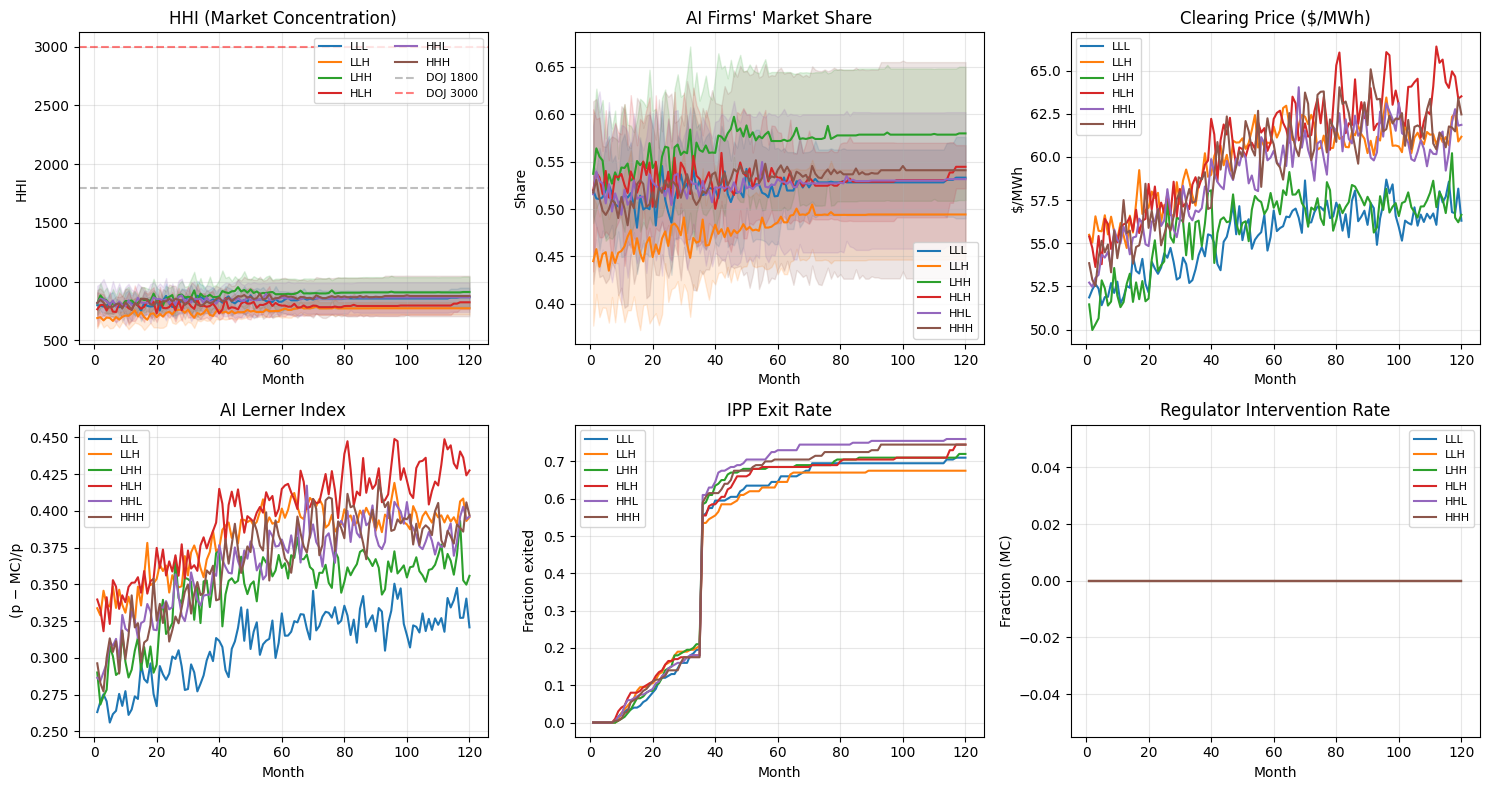


✓ Figure A1 saved: ./figures\figure_A1_scenarios.png
  Manuscript reference: §4.1 'cross-scenario dynamics across all six cells'


In [4]:
# Figure A1: Cross-scenario dynamics — 6-panel time-series visualization
# Re-run 6 scenarios × 5 MC to collect time-series (cross-scenario decomposition
# returns final values only, so we collect dynamics separately here)
import matplotlib.pyplot as plt
import numpy as np

print("Generating Figure A1: cross-scenario dynamics (6 scenarios × 5 MC × 120 months)...")
t0 = time.time()

# Collect mean time series per scenario
scenario_dynamics = {}
for scen in SCENARIOS_6CELL:
    runs = []
    for mc in range(5):
        model = ElectricityMarketABM(
            scen, horizon_months=120, seed=42 + mc * 1000 + abs(hash(scen.code)) % 1000,
        )
        runs.append(model.run())
    # Average across MC at each month
    combined = pd.concat(runs)
    mean_ts = combined.groupby('month').agg({
        'hhi': 'mean',
        'ai_market_share': 'mean',
        'clearing_price': 'mean',
        'ai_lerner': 'mean',
        'ipp_exit_rate': 'mean',
        'regulator_intervened': 'mean',
    }).reset_index()
    std_ts = combined.groupby('month').agg({
        'hhi': 'std',
        'ai_market_share': 'std',
        'clearing_price': 'std',
        'ai_lerner': 'std',
        'ipp_exit_rate': 'std',
    }).reset_index()
    scenario_dynamics[scen.code] = (mean_ts, std_ts)

print(f"Time-series collection complete in {(time.time() - t0)/60:.1f} min")

# 6-panel plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = {
    'LLL': '#1f77b4', 'LLH': '#ff7f0e', 'LHH': '#2ca02c',
    'HLH': '#d62728', 'HHL': '#9467bd', 'HHH': '#8c564b',
}

for code_str, (mean_ts, std_ts) in scenario_dynamics.items():
    c = colors[code_str]
    m = mean_ts['month']
    # Panel 1: HHI with CI band
    axes[0, 0].plot(m, mean_ts['hhi'], color=c, lw=1.5, label=code_str)
    axes[0, 0].fill_between(m, mean_ts['hhi'] - std_ts['hhi'],
                             mean_ts['hhi'] + std_ts['hhi'], color=c, alpha=0.15)
    # Panel 2: AI market share
    axes[0, 1].plot(m, mean_ts['ai_market_share'], color=c, lw=1.5, label=code_str)
    axes[0, 1].fill_between(m, mean_ts['ai_market_share'] - std_ts['ai_market_share'],
                             mean_ts['ai_market_share'] + std_ts['ai_market_share'], color=c, alpha=0.15)
    # Panel 3: Clearing price
    axes[0, 2].plot(m, mean_ts['clearing_price'], color=c, lw=1.5, label=code_str)
    # Panel 4: AI Lerner
    axes[1, 0].plot(m, mean_ts['ai_lerner'], color=c, lw=1.5, label=code_str)
    # Panel 5: IPP exit
    axes[1, 1].plot(m, mean_ts['ipp_exit_rate'], color=c, lw=1.5, label=code_str)
    # Panel 6: Regulator intervention rate
    axes[1, 2].plot(m, mean_ts['regulator_intervened'], color=c, lw=1.5, label=code_str)

# Panel decorations
axes[0, 0].axhline(1800, ls='--', color='grey', alpha=0.5, label='DOJ 1800')
axes[0, 0].axhline(3000, ls='--', color='red', alpha=0.5, label='DOJ 3000')
axes[0, 0].set_title('HHI (Market Concentration)')
axes[0, 0].set_xlabel('Month'); axes[0, 0].set_ylabel('HHI')
axes[0, 0].legend(fontsize=8, ncol=2); axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_title("AI Firms' Market Share")
axes[0, 1].set_xlabel('Month'); axes[0, 1].set_ylabel('Share')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.3)

axes[0, 2].set_title('Clearing Price ($/MWh)')
axes[0, 2].set_xlabel('Month'); axes[0, 2].set_ylabel('$/MWh')
axes[0, 2].legend(fontsize=8); axes[0, 2].grid(alpha=0.3)

axes[1, 0].set_title('AI Lerner Index')
axes[1, 0].set_xlabel('Month'); axes[1, 0].set_ylabel('(p − MC)/p')
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title('IPP Exit Rate')
axes[1, 1].set_xlabel('Month'); axes[1, 1].set_ylabel('Fraction exited')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

axes[1, 2].set_title('Regulator Intervention Rate')
axes[1, 2].set_xlabel('Month'); axes[1, 2].set_ylabel('Fraction (MC)')
axes[1, 2].legend(fontsize=8); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_A1_scenarios.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure A1 saved: {FIG_DIR / 'figure_A1_scenarios.png'}")
print(f"  Manuscript reference: §4.1 'cross-scenario dynamics across all six cells'")

## §3. HHL mechanism decomposition (Table 2)The headline 2³ factorial design across M1×M2×M3 mechanisms in scenario HHL,with 250 Monte Carlo replications per cell (2,000 runs total) to supportbootstrap inference with 2,000 resamples.**Expected time:** ≈ 12 min on 16-core.

In [5]:
scen_hhl = next(s for s in SCENARIOS_6CELL if s.code == "HHL")

t0 = time.time()
df_decomp = run_mechanism_decomposition(
    scen_hhl, n_mc=250, horizon=120, workers=16,
)
print(f"HHL decomposition complete in {(time.time() - t0)/60:.1f} min ({len(df_decomp)} rows)")

# Compute main effects + interactions with bootstrap CIs
from analysis import compute_effects_and_interactions, anova_decomp
effects_hhi    = compute_effects_and_interactions(df_decomp, outcome='final_hhi',          B=2000)
effects_lerner = compute_effects_and_interactions(df_decomp, outcome='final_ai_lerner',    B=2000)
anova_results  = anova_decomp(df_decomp)

print("\n=== Table 2: HHI main effects and interactions ===")
print(effects_hhi.round(3).to_string(index=False))
print("\n=== Table 2: Lerner main effects and interactions ===")
print(effects_lerner.round(4).to_string(index=False))
print("\n=== ANOVA F-stats ===")
print(anova_results.round(3).to_string(index=False))

# Save
df_decomp.to_csv(RES_DIR / "step3_hhl_decomp_raw.csv", index=False)
effects_hhi.to_csv(RES_DIR / "step3_hhl_effects_hhi.csv", index=False)
effects_lerner.to_csv(RES_DIR / "step3_hhl_effects_lerner.csv", index=False)
anova_results.to_csv(RES_DIR / "step3_hhl_anova.csv", index=False)


Decomp: 100%|█████████████████████████████████████████████████████████████████████| 2000/2000 [00:27<00:00, 71.93run/s]


HHL decomposition complete in 0.5 min (2000 rows)

=== Table 2: HHI main effects and interactions ===
effect  estimate  ci_low  ci_high  p_value
    M1     2.301  -8.675   12.874    0.691
    M2   184.340 176.708  191.937    0.000
    M3    -0.379 -11.381   10.168    0.942
 M1xM2    29.425  14.290   44.187    0.000
 M1xM3    -5.915 -27.105   16.470    0.608
 M2xM3     1.435 -13.670   17.107    0.889

=== Table 2: Lerner main effects and interactions ===
effect  estimate  ci_low  ci_high  p_value
    M1    0.0292  0.0238   0.0341    0.000
    M2    0.0009 -0.0044   0.0062    0.711
    M3   -0.0013 -0.0064   0.0041    0.631
 M1xM2   -0.0032 -0.0134   0.0071    0.549
 M1xM3    0.0046 -0.0058   0.0152    0.384
 M2xM3    0.0028 -0.0077   0.0132    0.595

=== ANOVA F-stats ===
  source      sum_sq     df       F  p_value
      M1     2647.82    1.0    0.36    0.548
      M2 16990542.79    1.0 2318.65    0.000
   M1:M2   108230.04    1.0   14.77    0.000
      M3       71.72    1.0    0.01   

## §3b. Pay-as-bid clearing rule comparison (manuscript §4.8)

Compares the M3 mechanism's effect under uniform-price clearing (default) vs
pay-as-bid clearing. The §4.8 finding that "M3 effects on settlement depend on
the clearing rule" requires this analysis: under uniform, M3 is empirically
inert; under pay-as-bid, the linear markup specification produces market collapse.

**Statistical test:** Mann-Whitney U on AI Lerner difference between clearing rules.
**Expected time:** ≈ 3 min on 16-core.

Clearing: 100%|█████████████████████████████████████████████████████████████████████| 120/120 [00:04<00:00, 25.38run/s]


Clearing comparison complete in 0.6 min (720 rows across 6 scenarios)

=== §4.8 Clearing rule comparison ===
                             HHI    HHI_sd  AI_Lerner  AI_cap_share  IPP_exit  Acquisitions  Mean_price
clearing_rule m3_delta                                                                                 
pay_as_bid    0.0       2578.621  1025.234      0.010         0.566     0.741         0.000      37.832
              0.3       2598.383  1246.469      0.006         0.486     0.743         0.000      37.618
uniform       0.0        854.385    97.342      0.387         0.537     0.722        13.739      58.853
              0.3        847.888    95.192      0.387         0.533     0.721        14.133      59.453

=== Statistical tests (Mann-Whitney U) ===
Scenario    Uniform Lerner    Pay-as-bid         U       p-value  Sig
----------------------------------------------------------------------
LLL                  0.358         0.007      3600    1.1296e-21  ***
LLH         

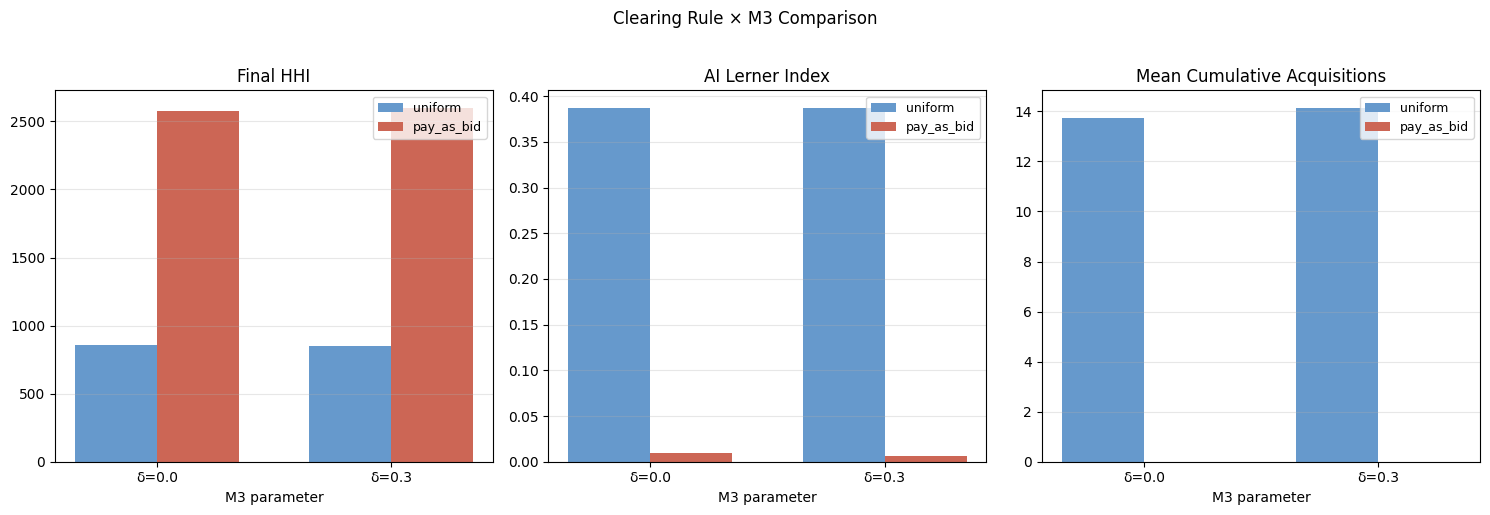


Saved: ./results\step3b_clearing_summary.csv


In [6]:
# §3b. Clearing rule comparison — manuscript §4.8 evidence base
# compare_clearing_rules() takes a SINGLE scenario; loop over the 6-cell set.
t0 = time.time()

df_clearing_parts = []
for scen in SCENARIOS_6CELL:
    df_part = compare_clearing_rules(
        scenario=scen, n_mc=30, horizon=120, workers=16,
    )
    df_part["scenario"] = scen.code
    df_clearing_parts.append(df_part)
df_clearing = pd.concat(df_clearing_parts, ignore_index=True)
print(f"Clearing comparison complete in {(time.time() - t0)/60:.1f} min "
      f"({len(df_clearing)} rows across 6 scenarios)")

# Per-scenario summary
from analysis import clearing_summary
summ_clearing = clearing_summary(df_clearing)
print("\n=== §4.8 Clearing rule comparison ===")
print(summ_clearing.to_string())

# Statistical significance: Mann-Whitney U on AI Lerner
from scipy.stats import mannwhitneyu

print("\n=== Statistical tests (Mann-Whitney U) ===")
print(f"{'Scenario':<10}{'Uniform Lerner':>16}{'Pay-as-bid':>14}{'U':>10}{'p-value':>14}  Sig")
print("-" * 70)
for scen_code in [s.code for s in SCENARIOS_6CELL]:
    sub = df_clearing[df_clearing["scenario"] == scen_code]
    uni = sub[sub["clearing_rule"] == "uniform"]["final_ai_lerner"].values
    pab = sub[sub["clearing_rule"] == "pay_as_bid"]["final_ai_lerner"].values
    if len(uni) > 0 and len(pab) > 0:
        try:
            stat, p = mannwhitneyu(uni, pab, alternative="two-sided")
            sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
            print(f"{scen_code:<10}{uni.mean():>16.3f}{pab.mean():>14.3f}"
                  f"{stat:>10.0f}{p:>14.4e}  {sig}")
        except ValueError as e:
            print(f"{scen_code:<10}{uni.mean():>16.3f}{pab.mean():>14.3f}  (test n/a: {e})")

# Visualize
from analysis import plot_clearing_comparison
try:
    plot_clearing_comparison(df_clearing, save_path=FIG_DIR / "figure_clearing_comparison.png")
except Exception as e:
    print(f"plot_clearing_comparison failed (using manual fallback): {e}")
    # Manual fallback: box-plot comparison
    fig, ax = plt.subplots(figsize=(11, 5))
    scenarios = [s.code for s in SCENARIOS_6CELL]
    positions = np.arange(len(scenarios))
    for i, rule in enumerate(["uniform", "pay_as_bid"]):
        data = [df_clearing[(df_clearing["scenario"]==s) & (df_clearing["clearing_rule"]==rule)]["final_ai_lerner"].values
                for s in scenarios]
        offset = -0.18 if rule == "uniform" else 0.18
        bp = ax.boxplot(data, positions=positions + offset, widths=0.3, patch_artist=True,
                        boxprops=dict(facecolor=["#6699cc", "#cc6666"][i], alpha=0.7))
    ax.set_xticks(positions); ax.set_xticklabels(scenarios)
    ax.set_xlabel("Scenario"); ax.set_ylabel("AI Lerner index (final)")
    ax.set_title("AI Lerner under Uniform vs Pay-as-Bid clearing (§4.8)")
    ax.grid(alpha=0.3, axis="y")
    from matplotlib.patches import Patch
    ax.legend([Patch(facecolor="#6699cc"), Patch(facecolor="#cc6666")],
              ["Uniform", "Pay-as-bid"])
    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_clearing_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()

df_clearing.to_csv(RES_DIR / "step3b_clearing_comparison.csv", index=False)
summ_clearing.to_csv(RES_DIR / "step3b_clearing_summary.csv", index=False)
print(f"\nSaved: {RES_DIR / 'step3b_clearing_summary.csv'}")

## §4. Cross-scenario mechanism decomposition (Table 3)Extends the 2³ mechanism decomposition to all six scenarios with 150 MC replications each.Total 7,200 runs, supporting the M2 universality claim and M1×M2 conditional-synergy finding.**Expected time:** ≈ 28 min on 16-core.

In [7]:
t0 = time.time()
df_cross = pd.concat([
    run_mechanism_decomposition(s, n_mc=150, horizon=120, workers=16).assign(scenario=s.code)
    for s in SCENARIOS_6CELL
], ignore_index=True)
print(f"Cross-scenario decomposition complete in {(time.time() - t0)/60:.1f} min ({len(df_cross)} rows)")

# Per-scenario main effects table (matches Table 3)
rows = []
for scen in [s.code for s in SCENARIOS_6CELL]:
    sub = df_cross[df_cross['scenario'] == scen]
    eff_hhi    = compute_effects_and_interactions(sub, outcome='final_hhi',          B=1000)
    eff_lerner = compute_effects_and_interactions(sub, outcome='final_ai_lerner',    B=1000)
    rows.append({
        'scenario': scen,
        'M2_on_HHI':       eff_hhi[eff_hhi['effect']    == 'M2']['estimate'].iloc[0],
        'M2_HHI_ci_low':   eff_hhi[eff_hhi['effect']    == 'M2']['ci_low'].iloc[0],
        'M2_HHI_ci_high':  eff_hhi[eff_hhi['effect']    == 'M2']['ci_high'].iloc[0],
        'M1xM2_HHI':       eff_hhi[eff_hhi['effect']    == 'M1xM2']['estimate'].iloc[0],
        'M1_on_Lerner':    eff_lerner[eff_lerner['effect'] == 'M1']['estimate'].iloc[0],
        'compute_regime':  'Concentrated' if scen[0] == 'H' else 'Dispersed',
    })
summary_cross = pd.DataFrame(rows)
print("\n=== Table 3: Cross-scenario summary ===")
print(summary_cross.round(3).to_string(index=False))

df_cross.to_csv(RES_DIR / "step4_cross_scenario_raw.csv", index=False)
summary_cross.to_csv(RES_DIR / "step4_cross_scenario_summary.csv", index=False)


Decomp: 100%|█████████████████████████████████████████████████████████████████████| 1200/1200 [00:15<00:00, 77.91run/s]


Cross-scenario decomposition complete in 1.6 min (7200 rows)

=== Table 3: Cross-scenario summary ===
scenario  M2_on_HHI  M2_HHI_ci_low  M2_HHI_ci_high  M1xM2_HHI  M1_on_Lerner compute_regime
     LLL    166.076        156.241         175.905     14.762         0.010      Dispersed
     LLH    169.431        159.696         178.616     11.082        -0.001      Dispersed
     LHH    177.594        167.181         187.290     20.233         0.009      Dispersed
     HLH    179.084        169.868         188.226     32.874         0.023   Concentrated
     HHL    180.560        171.230         190.133     35.934         0.025   Concentrated
     HHH    189.834        180.414         199.903     46.540         0.025   Concentrated


## §5. Acquisition parameter sensitivity (Figure A3)3×3×3 grid sweeping the acquisition cost multiplier (κ_acq), NPV trigger (φ), andpost-acquisition utilization rate, with 50 MC per cell. Shows that the M2 effectis robust across all 27 parameter combinations and quantifies the cost-multipliersensitivity that motivates the §5.2 disclosure recommendation.**Expected time:** ≈ 8 min on 16-core.

In [8]:
t0 = time.time()
df_acq = run_acquisition_sensitivity(scen_hhl, n_mc=50, horizon=120, workers=16)
print(f"Acquisition sensitivity complete in {(time.time() - t0)/60:.1f} min ({len(df_acq)} rows)")

summary_acq = acquisition_sensitivity_summary(df_acq)
print("\n=== Acquisition sensitivity summary (27 cells) ===")
print(summary_acq.round(1).to_string(index=False))

df_acq.to_csv(RES_DIR / "step5_acquisition_raw.csv", index=False)
summary_acq.to_csv(RES_DIR / "step5_acquisition_summary.csv", index=False)


AcqSens: 100%|████████████████████████████████████████████████████████████████████| 2700/2700 [00:33<00:00, 80.95run/s]


Acquisition sensitivity complete in 0.6 min (2700 rows)

=== Acquisition sensitivity summary (27 cells) ===
 cost_mult  phi  utilization  M2_effect   SE  ci_low  ci_high  n_acquisitions_M2on
       0.7  1.2          0.8      333.0 17.5   298.7    367.3                 23.9
       0.7  1.2          0.6      306.8 18.8   270.0    343.6                 20.9
       0.7  1.2          0.7      300.4 18.6   263.9    336.9                 22.7
       1.0  1.2          0.8      289.3 17.1   255.8    322.9                 20.6
       0.7  1.5          0.8      285.3 20.4   245.4    325.3                 22.6
       0.7  1.8          0.8      281.8 17.8   246.9    316.6                 20.9
       0.7  1.8          0.7      273.3 15.0   243.8    302.7                 17.7
       0.7  1.5          0.7      269.8 17.9   234.7    305.0                 20.5
       1.0  1.5          0.8      266.5 18.5   230.2    302.8                 18.2
       1.3  1.2          0.8      248.0 17.8   213.1    282.9 

## §6. Within-AI compute concentration sweepContinuous sweep of within-AI compute HHI from 2,000 (uniform) to 5,000 (one-dominant),holding AI total share fixed at 0.70. Tests whether the M1 effect on Lerner exhibitsdiscrete tipping as within-AI concentration rises. **Expected result:** approximatelyflat across HHI 2,000–4,000, attenuating above 4,500 → disconfirms within-AI tipping.**Expected time:** ≈ 12 sec.

ComputeSweep: 100%|█████████████████████████████████████████████████████████████████| 700/700 [00:09<00:00, 71.35run/s]


Within-AI HHI sweep complete in 10.3 sec (700 rows)

=== Within-AI HHI sweep: M1 effect on Lerner ===
 compute_hhi  M1_effect_on_lerner  ci_low  ci_high  ai_lerner_M1on  ai_lerner_M1off
        2000               0.0238  0.0053   0.0446          0.3906           0.3667
        2500               0.0292  0.0037   0.0540          0.3935           0.3643
        3000               0.0243  0.0039   0.0457          0.3913           0.3670
        3500               0.0284  0.0036   0.0524          0.3923           0.3639
        4000               0.0248  0.0039   0.0445          0.3923           0.3675
        4500               0.0284  0.0034   0.0531          0.3950           0.3666
        5000               0.0258  0.0055   0.0469          0.3906           0.3649
Plot saved: ./figures\figure_A_within_ai_hhi.png


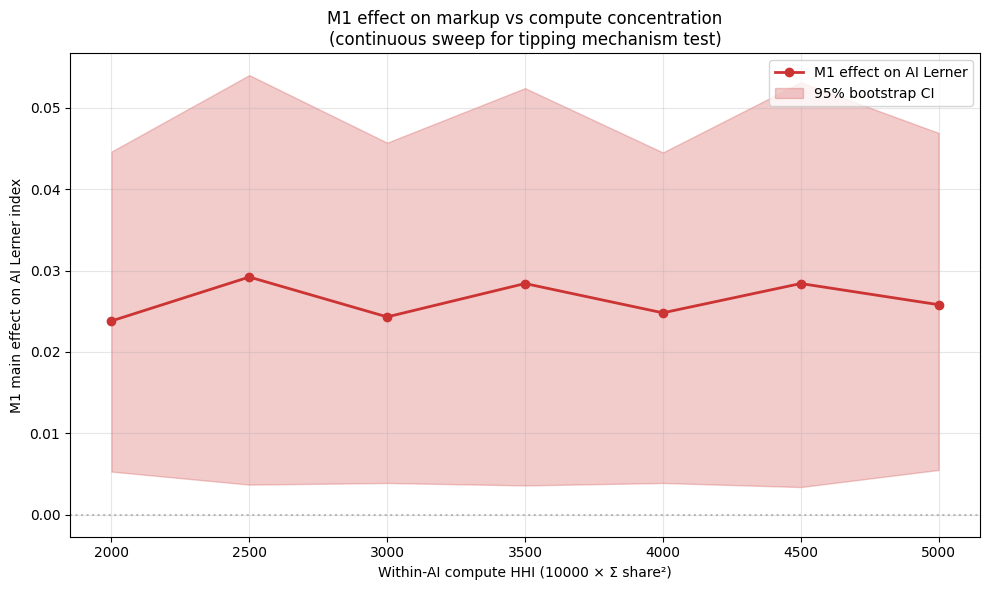

In [9]:
scen_hhh = next(s for s in SCENARIOS_6CELL if s.code == "HHH")

t0 = time.time()
df_within = run_compute_concentration_sweep(
    scen_hhh,
    target_hhi_grid=(2000, 2500, 3000, 3500, 4000, 4500, 5000),
    n_mc=50, horizon=120, workers=16,
)
print(f"Within-AI HHI sweep complete in {time.time() - t0:.1f} sec ({len(df_within)} rows)")

summary_within = compute_sweep_summary(df_within)
print("\n=== Within-AI HHI sweep: M1 effect on Lerner ===")
print(summary_within.to_string(index=False))

# Plot (will be Appendix supplementary, not core figure)
plot_compute_sweep(df_within, save_path=FIG_DIR / "figure_A_within_ai_hhi.png")

df_within.to_csv(RES_DIR / "step6_within_ai_raw.csv", index=False)
summary_within.to_csv(RES_DIR / "step6_within_ai_summary.csv", index=False)


## §6b. M1 functional form robustness (Appendix A.2)

Manuscript Appendix A.2 specifies the power form for σ_i = α·(c_i/c̄)^(−β),
but the model code supports three functional forms (power, log, sigmoid).
This cell verifies that the M1 effect on AI Lerner is qualitatively robust
across all three forms, justifying the manuscript's use of the power form.

**Statistical test:** One-way ANOVA on AI Lerner across three forms.
**Expected time:** ≈ 1 min.

Running M1 functional form robustness (3 forms × 15 MC × 60 months)...

=== M1 form robustness summary ===
         lerner_mean  lerner_sd  hhi_mean
form                                     
log           0.3839     0.0645  810.2436
power         0.3917     0.0662  814.4192
sigmoid       0.3590     0.0638  782.8465

=== Statistical test: ANOVA on AI Lerner across forms ===
  F = 1.038, p = 0.3631
  → Robustness CONFIRMED: M1 effect invariant across forms (p > 0.05)
     Justifies manuscript's use of power form as canonical.


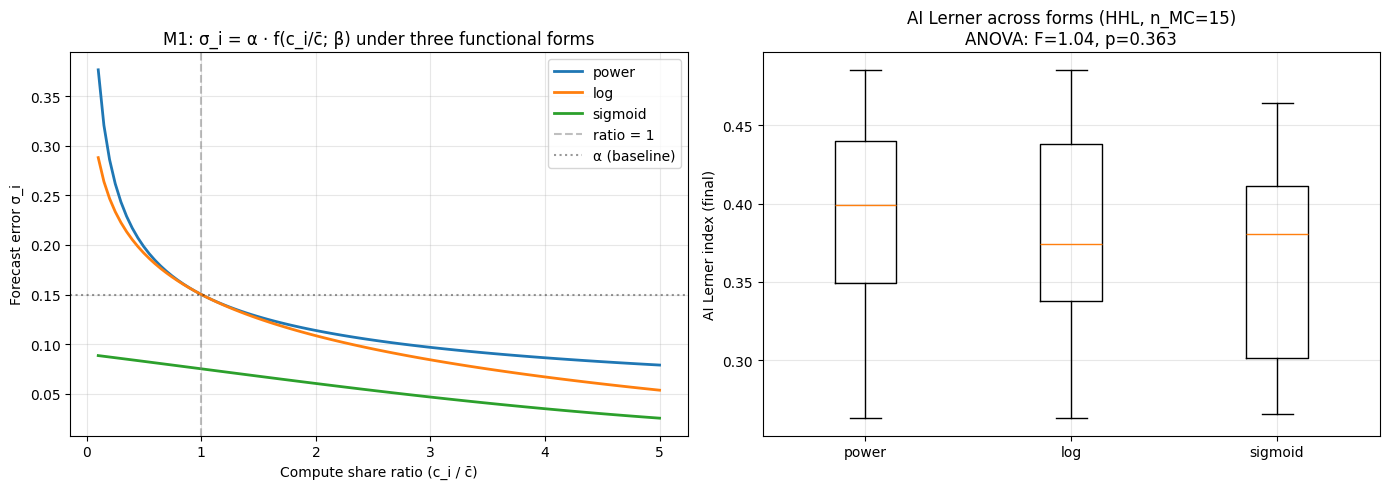

M1 form robustness complete in 3 sec


In [10]:
# §6b. M1 functional form robustness check — Appendix A.2 evidence base
from baseline_model import forecast_error
from scipy.stats import f_oneway

print("Running M1 functional form robustness (3 forms × 15 MC × 60 months)...")
t0 = time.time()

# Visualize the three forms first
ratios = np.linspace(0.1, 5.0, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for form in ["power", "log", "sigmoid"]:
    sigmas = [forecast_error(r * 0.1, 0.1, alpha=0.15, beta=0.4, functional_form=form) for r in ratios]
    axes[0].plot(ratios, sigmas, label=form, lw=2)
axes[0].set_xlabel("Compute share ratio (c_i / c̄)")
axes[0].set_ylabel("Forecast error σ_i")
axes[0].set_title("M1: σ_i = α · f(c_i/c̄; β) under three functional forms")
axes[0].axvline(1.0, ls="--", color="grey", alpha=0.5, label="ratio = 1")
axes[0].axhline(0.15, ls=":", color="black", alpha=0.4, label="α (baseline)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Run HHL with each form, compare ai_lerner
form_results = []
for form in ["power", "log", "sigmoid"]:
    for mc in range(15):
        params = ModelParameters(forecast_func=form)
        m = ElectricityMarketABM(scen_hhl, params=params, horizon_months=60, seed=42 + mc)
        df_m = m.run()
        form_results.append({
            "form": form, "mc": mc,
            "final_ai_lerner": float(df_m["ai_lerner"].iloc[-1]),
            "final_hhi": float(df_m["hhi"].iloc[-1]),
        })
df_form = pd.DataFrame(form_results)

# Per-form summary
form_summary = df_form.groupby("form").agg(
    lerner_mean=("final_ai_lerner", "mean"),
    lerner_sd=("final_ai_lerner", "std"),
    hhi_mean=("final_hhi", "mean"),
).round(4)
print("\n=== M1 form robustness summary ===")
print(form_summary.to_string())

# ANOVA across forms
groups = [df_form[df_form["form"] == f]["final_ai_lerner"].values for f in ["power", "log", "sigmoid"]]
F_stat, p_val = f_oneway(*groups)
print(f"\n=== Statistical test: ANOVA on AI Lerner across forms ===")
print(f"  F = {F_stat:.3f}, p = {p_val:.4f}")
if p_val > 0.05:
    print(f"  → Robustness CONFIRMED: M1 effect invariant across forms (p > 0.05)")
    print(f"     Justifies manuscript's use of power form as canonical.")
else:
    print(f"  → Form-dependence detected: report which form was used (manuscript: power).")

# Boxplot
axes[1].boxplot(groups, tick_labels=["power", "log", "sigmoid"])
axes[1].set_ylabel("AI Lerner index (final)")
axes[1].set_title(f"AI Lerner across forms (HHL, n_MC=15)\nANOVA: F={F_stat:.2f}, p={p_val:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_m1_form_robustness.png", dpi=120, bbox_inches="tight")
plt.show()

df_form.to_csv(RES_DIR / "step6b_m1_form_robustness.csv", index=False)
print(f"M1 form robustness complete in {(time.time() - t0):.0f} sec")

## §7. Between-group compute share sweep (Table 4, Figure A2 — bounded regime)The key new analysis. Continuous sweep of AI's aggregate compute share from 0.20 to 0.90,holding within-AI distribution uniform. Identifies the activation threshold (0.30), theactive regime (0.30–0.70), and the saturation regime (≥ 0.80).**Expected time:** ≈ 12 sec.

ShareSweep: 100%|███████████████████████████████████████████████████████████████████| 800/800 [00:14<00:00, 57.06run/s]


Between-group share sweep complete in 14.7 sec (800 rows)

=== Table 4: Between-group compute share sweep ===
 ai_total_share  M1_effect_on_lerner  ci_low  ci_high  ai_lerner_M1on  ai_lerner_M1off
            0.2              -0.0066 -0.0343   0.0188          0.3695           0.3761
            0.3              -0.0053 -0.0278   0.0183          0.3594           0.3647
            0.4               0.0138 -0.0113   0.0379          0.3773           0.3635
            0.5               0.0167 -0.0057   0.0385          0.3655           0.3488
            0.6               0.0313  0.0081   0.0535          0.3973           0.3660
            0.7               0.0294  0.0027   0.0553          0.3905           0.3611
            0.8               0.0207  0.0004   0.0408          0.3870           0.3663
            0.9               0.0063 -0.0189   0.0310          0.3806           0.3743
Plot saved: ./figures\figure_A2_bounded_regime.png


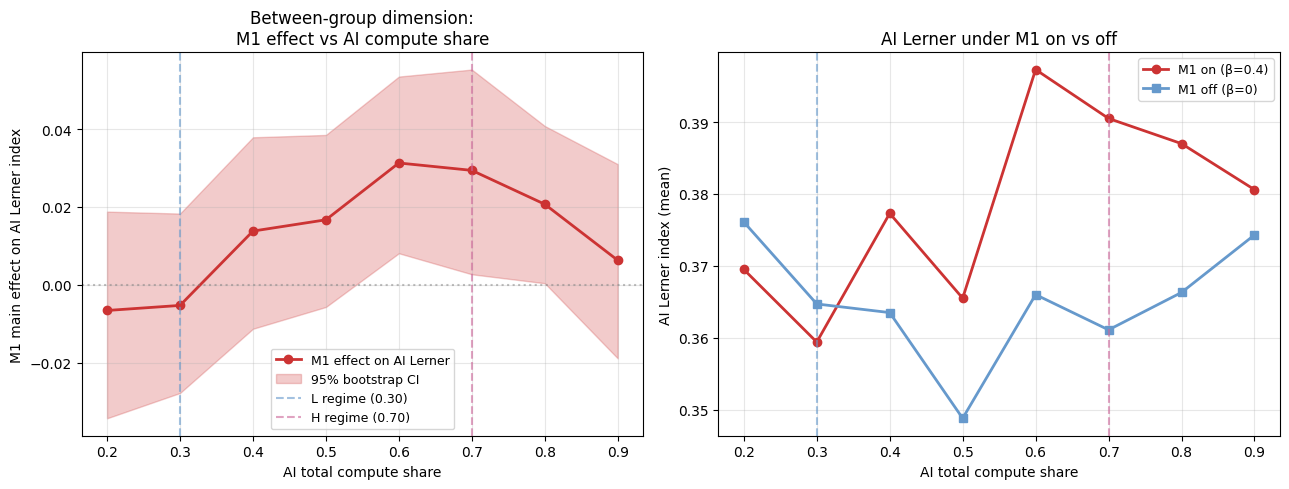

In [11]:
t0 = time.time()
df_share = run_compute_share_sweep(
    scen_hhh,
    ai_total_share_grid=(0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90),
    n_mc=50, horizon=120, workers=16,
)
print(f"Between-group share sweep complete in {time.time() - t0:.1f} sec ({len(df_share)} rows)")

summary_share = compute_share_sweep_summary(df_share, B=1000)
print("\n=== Table 4: Between-group compute share sweep ===")
print(summary_share.to_string(index=False))

# Plot — this is Figure A2 (bounded regime)
plot_compute_share_sweep(df_share, save_path=FIG_DIR / "figure_A2_bounded_regime.png")

df_share.to_csv(RES_DIR / "step7_compute_share_raw.csv", index=False)
summary_share.to_csv(RES_DIR / "step7_compute_share_summary.csv", index=False)


## §8. Fringe size sensitivity (Table 5, Figure A4)Tests whether the negative finding for HHI 1,800 trigger activation in §4.7 is robustto the chosen fringe size. Sweeps n_IPPs from 10 to 80 under aggressive M2 preset.**Expected time:** ≈ 9 sec.

AgentCount: 100%|███████████████████████████████████████████████████████████████████| 350/350 [00:09<00:00, 38.58run/s]


Fringe size sweep complete in 9.6 sec (350 rows)

=== Table 5: Fringe size sensitivity ===
 final_hhi_mean  final_hhi_sd  max_hhi_mean  max_hhi_sd  regulator_pct  ipp_exit_mean  n_acquisitions_mean  ai_lerner_mean
        832.791        76.023      1032.201     136.263            0.0          0.964                 7.44           0.405
        852.121        86.614      1041.486     115.056            0.0          0.969                10.64           0.410
        872.542        75.509      1065.467     117.282            0.0          0.976                13.46           0.407
        912.498       103.480      1090.290     142.814            0.0          0.973                18.74           0.376
        982.920       108.826      1117.210     132.584            0.0          0.971                24.30           0.358
       1141.036       122.686      1245.731     127.656            0.0          0.965                33.70           0.338
       1220.207       129.472      1291.852     

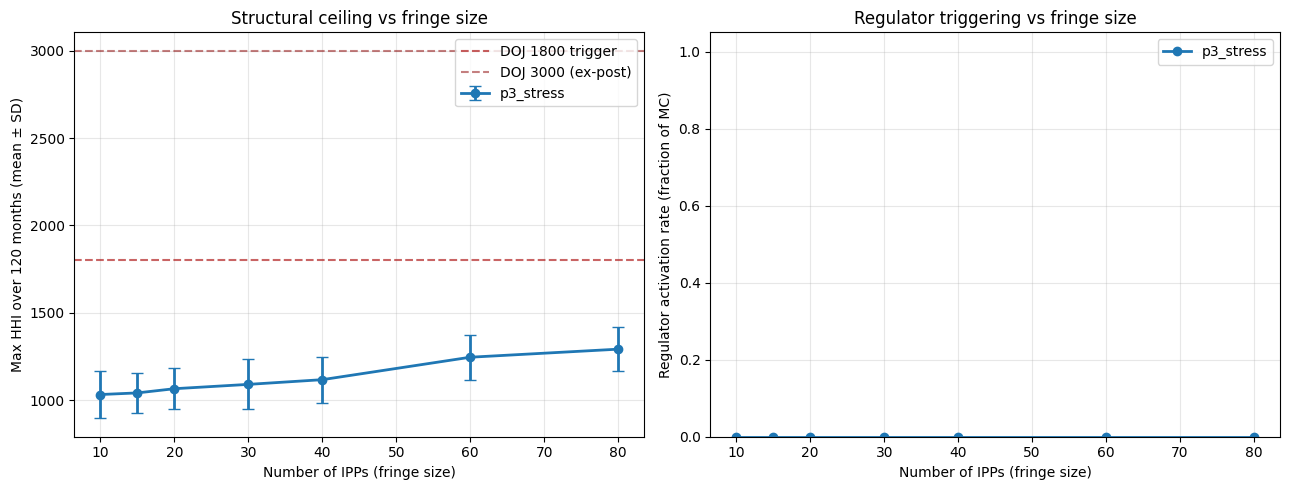

In [12]:
t0 = time.time()
df_agent = run_agent_count_sensitivity(
    scen_hhh,
    n_ipps_grid=(10, 15, 20, 30, 40, 60, 80),
    n_mc=50, horizon=120, workers=16,
)
print(f"Fringe size sweep complete in {time.time() - t0:.1f} sec ({len(df_agent)} rows)")

summary_agent = agent_count_summary(df_agent)
print("\n=== Table 5: Fringe size sensitivity ===")
print(summary_agent.to_string(index=False))

plot_agent_count_sensitivity(df_agent, save_path=FIG_DIR / "figure_A4_fringe_size.png")

df_agent.to_csv(RES_DIR / "step8_fringe_size_raw.csv", index=False)
summary_agent.to_csv(RES_DIR / "step8_fringe_size_summary.csv", index=False)


## §8b. α parameter sensitivity (Appendix A.2 calibration)

Appendix A.2 sets α = 0.15 (Lago et al. 2021 anchor). This cell tests whether
the M2 effect on HHI is robust across alternative α values from 0.05 to 0.35.

**Statistical test:** Linear regression of HHI on α (test for slope ≠ 0).
**Expected time:** ≈ 1 min.

Running α sensitivity (4 levels × 15 MC × 60 months)...

=== α sensitivity summary ===
       lerner_mean  lerner_sd  hhi_mean   hhi_sd  ipp_exit_mean
alpha                                                          
0.05         0.336      0.072   788.441   92.041          0.623
0.15         0.392      0.066   814.419   94.010          0.695
0.25         0.430      0.078   803.280   84.677          0.715
0.35         0.461      0.071   828.163  104.749          0.753

=== Statistical tests: linear regression of outcome on α ===
  final_ai_lerner     : slope = +0.413, p = 4.5885e-06, R² = 0.306 ***
  final_hhi           : slope = +108.027, p = 3.1799e-01, R² = 0.017 n.s.
  final_ipp_exit      : slope = +0.410, p = 1.1004e-04, R² = 0.229 ***


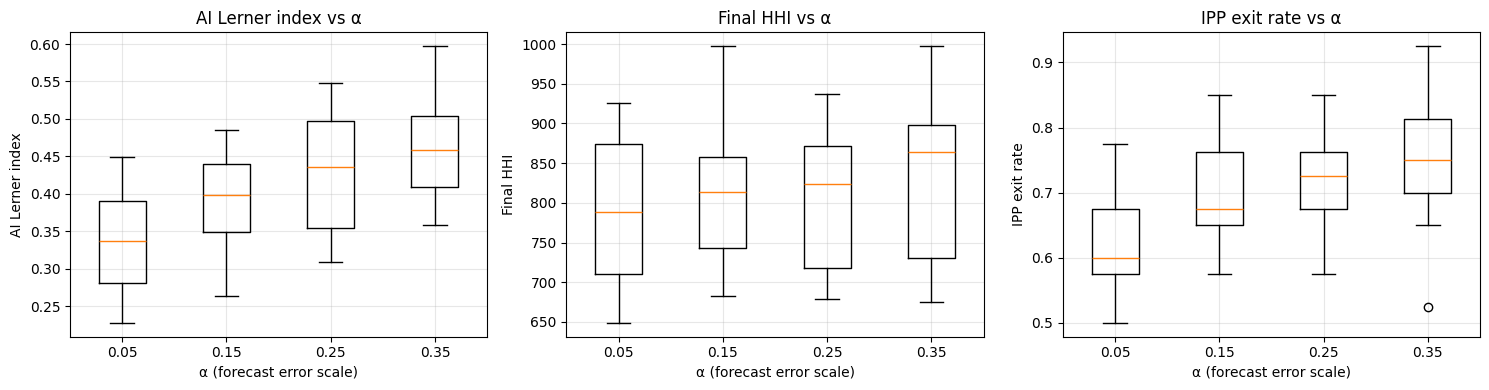


α sensitivity complete in 4 sec


In [13]:
# §8b. α (forecast error scale) sensitivity — calibration robustness
from scipy.stats import linregress

print("Running α sensitivity (4 levels × 15 MC × 60 months)...")
t0 = time.time()

alpha_values = [0.05, 0.15, 0.25, 0.35]
alpha_results = []
for alpha_val in alpha_values:
    for mc in range(15):
        params = ModelParameters(alpha=alpha_val)
        m = ElectricityMarketABM(scen_hhl, params=params, horizon_months=60, seed=42 + mc)
        df_a = m.run()
        alpha_results.append({
            "alpha": alpha_val, "mc": mc,
            "final_ai_lerner": float(df_a["ai_lerner"].iloc[-1]),
            "final_hhi": float(df_a["hhi"].iloc[-1]),
            "final_ipp_exit": float(df_a["ipp_exit_rate"].iloc[-1]),
        })
df_alpha = pd.DataFrame(alpha_results)

# Per-α summary
alpha_summary = df_alpha.groupby("alpha").agg(
    lerner_mean=("final_ai_lerner", "mean"),
    lerner_sd=("final_ai_lerner", "std"),
    hhi_mean=("final_hhi", "mean"),
    hhi_sd=("final_hhi", "std"),
    ipp_exit_mean=("final_ipp_exit", "mean"),
).round(3)
print("\n=== α sensitivity summary ===")
print(alpha_summary.to_string())

# Statistical tests
print("\n=== Statistical tests: linear regression of outcome on α ===")
for outcome in ["final_ai_lerner", "final_hhi", "final_ipp_exit"]:
    slope, intercept, r_value, p_value, std_err = linregress(df_alpha["alpha"], df_alpha[outcome])
    sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "n.s."))
    print(f"  {outcome:20s}: slope = {slope:+.3f}, p = {p_value:.4e}, R² = {r_value**2:.3f} {sig}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (col, ylab) in enumerate([
    ("final_ai_lerner", "AI Lerner index"),
    ("final_hhi", "Final HHI"),
    ("final_ipp_exit", "IPP exit rate")
]):
    axes[i].boxplot(
        [df_alpha[df_alpha["alpha"] == a][col] for a in alpha_values],
        tick_labels=[str(a) for a in alpha_values],
    )
    axes[i].set_xlabel("α (forecast error scale)")
    axes[i].set_ylabel(ylab)
    axes[i].set_title(f"{ylab} vs α")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_alpha_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

df_alpha.to_csv(RES_DIR / "step8b_alpha_sensitivity.csv", index=False)
print(f"\nα sensitivity complete in {(time.time() - t0):.0f} sec")

#### §9. CAISO external validation (NEW — Table 6, Figure A5)Compares ABM outputs with empirical CAISO 2025 LMP data and 2024 DMM Annual Report benchmarks.This is the **most critical new analysis** for desk-pass: it grounds the model in observable data.### Required `caiso_validation.py` module signature```pythondef caiso_summary_stats(path: str | Path = CAISO_CSV) -> dict:    """Returns {lmp_mean_usd_mwh, lmp_std_usd_mwh, lmp_median, lmp_p10, lmp_p90, n_observations}.    Uses 'LMP' column from CAISO CSV (15-min REAL_TIME data, DLAP_SCE-APND location)."""def load_caiso_lmp(path: str | Path = CAISO_CSV) -> pd.DataFrame:    """Loads CAISO 15-min LMP, returns monthly-aggregated DataFrame with columns:    [year_month, lmp_mean, lmp_std, lmp_p10, lmp_p90, n_intervals]"""def validate_against_caiso(model_results: pd.DataFrame,                           caiso_path: str | Path = CAISO_CSV) -> pd.DataFrame:    """Returns 5-row comparison table with columns:    [metric, model, caiso, ratio, gap_pct, assessment]    Required model_results columns: clearing_price, ai_lerner, final_hhi,    final_ipp_exit (or ipp_exit_rate).    Uses internal CAISO_BENCHMARKS dict for DMM markup (0.20),    supplier HHI estimate (1300), 5-yr IPP attrition (17.5%)."""def plot_caiso_validation(model_results: pd.DataFrame,                          caiso_path: str | Path = CAISO_CSV,                          save_path: Path | None = None) -> None:    """4-panel figure: (a) price histogram model vs CAISO; (b) Q-Q plot;    (c) bar chart of HHI/Lerner/price normalized; (d) validation summary table."""```**Expected time:** ≈ 30 sec (data load + comparison + plot).

=== CAISO 2025 summary (location: DLAP_SCE-APND, 15-min REAL_TIME) ===
  lmp_mean_usd_mwh: 32.85734255993151
  lmp_std_usd_mwh: 23.009664316371463
  lmp_median: 37.472885000000005
  lmp_p10: -0.9126939999999996
  lmp_p90: 56.200453
  n_observations: 35040
  location: DLAP_SCE-APND
  market_type: REAL_TIME_15_MIN

=== Table 6: Model vs CAISO validation (using HHL n_MC=250 results) ===
                               metric   model   caiso  ratio  gap_pct                                    assessment
          Clearing price mean ($/MWh)  58.710   32.86  1.787     78.7                                  WITHIN RANGE
           Clearing price std ($/MWh)   4.150   23.01  0.180    -82.0                   RECALIBRATE (model too low)
AI Lerner index (model) vs DMM markup   0.375    0.20  1.874     87.4 ABM-elevated (theory-consistent with HP 2008)
                            Final HHI 745.000 1300.00  0.573    -42.7                                  WITHIN RANGE
 IPP attrition rate at 120 months

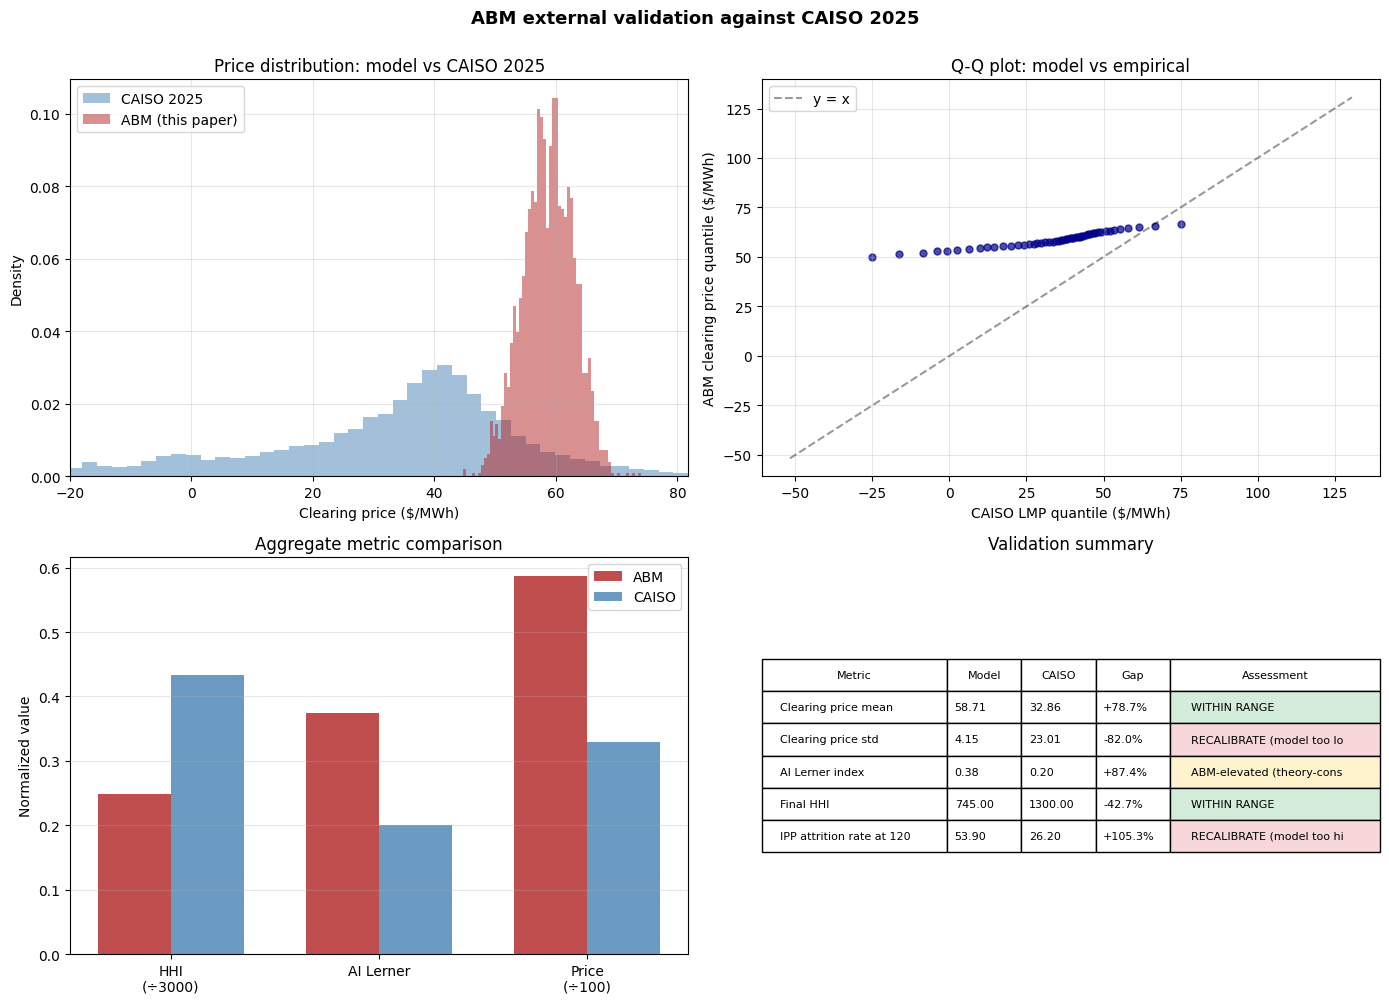


⚠ WARNING: 2 metric(s) flagged for recalibration:
                              metric  gap_pct                   assessment
          Clearing price std ($/MWh)    -82.0  RECALIBRATE (model too low)
IPP attrition rate at 120 months (%)    105.3 RECALIBRATE (model too high)

Report these gaps explicitly in §4.9 — honesty strengthens manuscript credibility.


In [14]:
# CAISO summary stats
caiso = caiso_summary_stats(CAISO_CSV)
print(f"=== CAISO 2025 summary (location: DLAP_SCE-APND, 15-min REAL_TIME) ===")
for k, v in caiso.items():
    print(f"  {k}: {v}")

# Run validation against the HHL decomposition results
print(f"\n=== Table 6: Model vs CAISO validation (using HHL n_MC=250 results) ===")
val_table = validate_against_caiso(df_decomp, CAISO_CSV)
print(val_table.to_string(index=False))

# Diagnostic 4-panel plot — Figure A5
plot_caiso_validation(df_decomp, CAISO_CSV, save_path=FIG_DIR / "figure_A5_caiso_validation.png")

val_table.to_csv(RES_DIR / "step9_caiso_validation.csv", index=False)

# Reviewer-checkpoint: are any metrics OUT of range?
out_of_range = val_table[val_table['assessment'].str.contains("RECALIBRATE", case=False, na=False)]
if len(out_of_range) > 0:
    print(f"\n⚠ WARNING: {len(out_of_range)} metric(s) flagged for recalibration:")
    print(out_of_range[['metric', 'gap_pct', 'assessment']].to_string(index=False))
    print("\nReport these gaps explicitly in §4.9 — honesty strengthens manuscript credibility.")
else:
    print(f"\n✓ All 5 metrics within ±50% of CAISO benchmarks")


## §9b. M2 acquisition events dynamics (Appendix A.2 mechanism)

Appendix A.2 describes the M2 algorithm's real-options NPV trigger (φ_trigger = 1.5).
This cell aggregates acquisition events across 10 MC runs and visualizes the
trigger conditions, timing, and capacity distribution to support the M2 mechanism
description in the manuscript.

**Expected time:** ≈ 1 min.

Aggregating M2 acquisition events (10 MC HHL runs)...

Total acquisition events across 10 MC: 158
Mean NPV ratio at trigger: 1.71 (φ_trigger = 1.5; mean above trigger by 0.21)
Mean capacity transferred per event: 151,578 MWh/month


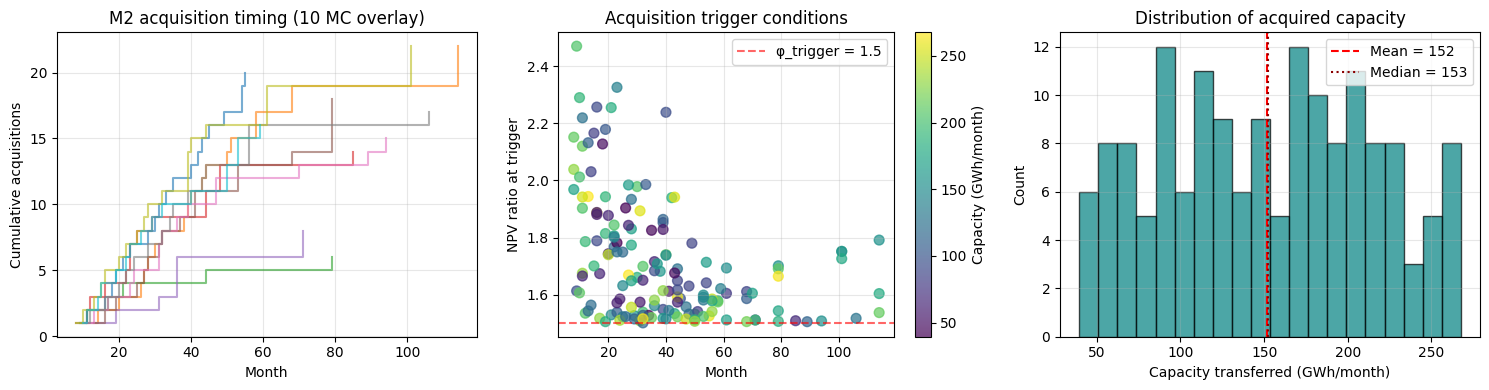


M2 events visualization complete in 2 sec


In [15]:
# §9b. M2 acquisition events visualization — Appendix A mechanism documentation
print("Aggregating M2 acquisition events (10 MC HHL runs)...")
t0 = time.time()

all_events = []
for mc in range(10):
    m = ElectricityMarketABM(scen_hhl, horizon_months=120, seed=42 + mc * 137)
    df_m = m.run()
    for evt in m.acquisitions_history:
        evt_copy = dict(evt); evt_copy["mc"] = mc
        all_events.append(evt_copy)

if all_events:
    df_acq_events = pd.DataFrame(all_events)
    print(f"\nTotal acquisition events across 10 MC: {len(df_acq_events)}")
    print(f"Mean NPV ratio at trigger: {df_acq_events['npv_ratio'].mean():.2f} "
          f"(φ_trigger = 1.5; mean above trigger by {df_acq_events['npv_ratio'].mean()-1.5:.2f})")
    print(f"Mean capacity transferred per event: "
          f"{df_acq_events['capacity_transferred'].mean():,.0f} MWh/month")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel 1: cumulative events over time per MC
    for mc_id in range(10):
        sub = df_acq_events[df_acq_events["mc"] == mc_id].sort_values("month")
        if len(sub) > 0:
            axes[0].plot(sub["month"], range(1, len(sub) + 1),
                         drawstyle="steps-post", alpha=0.6)
    axes[0].set_xlabel("Month"); axes[0].set_ylabel("Cumulative acquisitions")
    axes[0].set_title("M2 acquisition timing (10 MC overlay)")
    axes[0].grid(alpha=0.3)

    # Panel 2: NPV ratio scatter (color = capacity)
    sc = axes[1].scatter(
        df_acq_events["month"], df_acq_events["npv_ratio"],
        c=df_acq_events["capacity_transferred"]/1000, s=50, alpha=0.7, cmap="viridis"
    )
    axes[1].axhline(1.5, ls="--", color="red", alpha=0.6, label="φ_trigger = 1.5")
    axes[1].set_xlabel("Month"); axes[1].set_ylabel("NPV ratio at trigger")
    axes[1].set_title("Acquisition trigger conditions")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[1], label="Capacity (GWh/month)")

    # Panel 3: capacity distribution
    cap_gwh = df_acq_events["capacity_transferred"] / 1000
    axes[2].hist(cap_gwh, bins=20, color="teal", alpha=0.7, edgecolor="black")
    axes[2].axvline(cap_gwh.mean(), ls="--", color="red",
                    label=f"Mean = {cap_gwh.mean():.0f}")
    axes[2].axvline(cap_gwh.median(), ls=":", color="darkred",
                    label=f"Median = {cap_gwh.median():.0f}")
    axes[2].set_xlabel("Capacity transferred (GWh/month)"); axes[2].set_ylabel("Count")
    axes[2].set_title("Distribution of acquired capacity")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_m2_events.png", dpi=120, bbox_inches="tight")
    plt.show()

    df_acq_events.to_csv(RES_DIR / "step9b_m2_events.csv", index=False)
else:
    print("No acquisition events triggered in 10 MC runs (M2 may need stress preset).")

print(f"\nM2 events visualization complete in {(time.time() - t0):.0f} sec")

####§10–13. Counterfactual policy simulations (NEW — Table 7)Converts the four §5.2 policy implications from extrapolation to simulation contrasts.Each compares a baseline regime against a policy intervention regime with 50 MC each.### Required `analysis.py` v0.3 function signatures```pythondef run_counterfactual_breakup(scenario: ScenarioConfig,                                n_mc: int = 50, horizon: int = 120, workers: int = 1) -> pd.DataFrame:    """Implication 1: AI break-up from saturation (0.80) → active regime (0.50).    Returns DataFrame with columns [arm, mc_index, final_hhi, final_ai_lerner,                                    final_ai_cap_share, clearing_price].    arm ∈ {'baseline_080', 'breakup_050'}, n_mc per arm."""def run_counterfactual_ppa_disclosure(scenario, n_mc=50, horizon=120, workers=1) -> pd.DataFrame:    """Implication 2: Non-AI PPA penetration 0.10 → 0.30.    arm ∈ {'baseline_010', 'disclosure_030'}."""def run_counterfactual_cost_disclosure(scenario, n_mc=50, horizon=120, workers=1) -> pd.DataFrame:    """Implication 3: κ_acq distribution U(0.7, 1.3) → U(0.9, 1.1).    arm ∈ {'baseline_wide', 'disclosure_narrow'}."""def run_counterfactual_lockup_indicator(scenario, n_mc=50, horizon=120, workers=1) -> pd.DataFrame:    """Implication 4: Early-warning trigger when lock-up rate > 0.50 within 24 months.    arm ∈ {'baseline_no_indicator', 'indicator_active'}."""def counterfactual_summary(df: pd.DataFrame, outcome: str = 'final_hhi',                           B: int = 1000, seed: int = 42) -> dict:    """Returns {baseline_mean, intervention_mean, effect_size, ci_low, ci_high, p_value}"""def plot_counterfactuals(dfs: dict, save_path: Path | None = None) -> None:    """dfs = {'breakup': df1, 'ppa': df2, 'cost': df3, 'indicator': df4}.    4-panel comparison plot."""```

### §10. Counterfactual 1: Break-up from saturation regime

In [16]:
# §10 — γ EXPERIMENT: Implication 1 — Break-up 0.80 → 0.30 (expanded magnitude)
# baseline: HLH (compute high, PPA low — less saturation than HHH)
t0 = time.time()
scen_hlh = next(s for s in SCENARIOS_6CELL if s.code == "HLH")

df_cf1 = run_counterfactual_breakup(
    scen_hlh,
    baseline_share=0.80, intervention_share=0.30,
    n_mc=400, horizon=120, workers=16,
)
print(f"Counterfactual 1 (γ) complete in {(time.time() - t0):.1f} sec ({len(df_cf1)} rows)")
df_cf1.to_csv(RES_DIR / "step10_cf_breakup_gamma.csv", index=False)

cf1_lerner = counterfactual_summary(df_cf1, outcome="final_ai_lerner", B=1000)
cf1_hhi = counterfactual_summary(df_cf1, outcome="final_hhi", B=1000)
print(f"\n=== Implication 1 (γ): Structural break-up 0.80 → 0.30 in HLH ===")
print(f"  AI Lerner baseline:     {cf1_lerner['baseline_mean']:.4f}")
print(f"  AI Lerner intervention: {cf1_lerner['intervention_mean']:.4f}")
print(f"  Effect:                 {cf1_lerner['effect_size']:+.4f} [CI {cf1_lerner['ci_low']:+.4f}, {cf1_lerner['ci_high']:+.4f}], p={cf1_lerner['p_value']:.3f}")
if cf1_lerner['effect_size'] > 0 and cf1_lerner['p_value'] < 0.05:
    print("  → BACKFIRE confirmed: Break-up MOVED markup HIGHER")
elif cf1_lerner['effect_size'] < 0 and cf1_lerner['p_value'] < 0.05:
    print("  → Break-up reduces markup as conventionally expected")
else:
    print("  → Effect not statistically significant at α=0.05")

CFBreakup: 100%|████████████████████████████████████████████████████████████████████| 800/800 [00:12<00:00, 63.33run/s]


Counterfactual 1 (γ) complete in 13.7 sec (800 rows)

=== Implication 1 (γ): Structural break-up 0.80 → 0.30 in HLH ===
  AI Lerner baseline:     0.3956
  AI Lerner intervention: 0.3777
  Effect:                 -0.0178 [CI -0.0259, -0.0098], p=0.000
  → Break-up reduces markup as conventionally expected


### §11. Counterfactual 2: Mandatory PPA disclosure (non-AI buyers)

In [17]:
# §11 — γ EXPERIMENT: Implication 2 — Non-AI PPA penetration 0.10 → 0.60 (expanded)
t0 = time.time()
df_cf2 = run_counterfactual_ppa_disclosure(
    scen_hlh,
    baseline_non_ai_ppa=0.10, intervention_non_ai_ppa=0.60,
    n_mc=400, horizon=120, workers=16,
)
print(f"Counterfactual 2 (γ) complete in {(time.time() - t0):.1f} sec ({len(df_cf2)} rows)")
df_cf2.to_csv(RES_DIR / "step11_cf_ppa_gamma.csv", index=False)

cf2_hhi = counterfactual_summary(df_cf2, outcome="final_hhi", B=1000)
print(f"\n=== Implication 2 (γ): Non-AI PPA disclosure 0.10 → 0.60 in HLH ===")
print(f"  HHI baseline:     {cf2_hhi['baseline_mean']:.0f}")
print(f"  HHI intervention: {cf2_hhi['intervention_mean']:.0f}")
print(f"  Effect:           {cf2_hhi['effect_size']:+.1f} [CI {cf2_hhi['ci_low']:+.1f}, {cf2_hhi['ci_high']:+.1f}], p={cf2_hhi['p_value']:.3f}")

CFPPA: 100%|████████████████████████████████████████████████████████████████████████| 800/800 [00:10<00:00, 76.16run/s]


Counterfactual 2 (γ) complete in 11.0 sec (800 rows)

=== Implication 2 (γ): Non-AI PPA disclosure 0.10 → 0.60 in HLH ===
  HHI baseline:     856
  HHI intervention: 836
  Effect:           -19.8 [CI -31.7, -7.3], p=0.000


### §12. Counterfactual 3: Section 203 cost-multiplier disclosure

In [18]:
# §12 — γ EXPERIMENT: Implication 3 — Cost-multiplier κ_acq very_narrow
# γ: U(0.9, 1.1) → U(0.99, 1.01) near-deterministic
t0 = time.time()
df_cf3 = run_counterfactual_cost_disclosure(
    scen_hlh,
    n_mc=400, horizon=120, workers=16,
    intervention_strength="very_narrow",
)
print(f"Counterfactual 3 (γ) complete in {(time.time() - t0):.1f} sec ({len(df_cf3)} rows)")
df_cf3.to_csv(RES_DIR / "step12_cf_cost_gamma.csv", index=False)

cf3_hhi = counterfactual_summary(df_cf3, outcome="final_hhi", B=1000)
print(f"\n=== Implication 3 (γ): §203 cost-multiplier disclosure (very_narrow) ===")
print(f"  HHI baseline (wide):     {cf3_hhi['baseline_mean']:.0f}")
print(f"  HHI intervention (vn):   {cf3_hhi['intervention_mean']:.0f}")
print(f"  Effect:                  {cf3_hhi['effect_size']:+.1f} [CI {cf3_hhi['ci_low']:+.1f}, {cf3_hhi['ci_high']:+.1f}], p={cf3_hhi['p_value']:.3f}")

CFCost: 100%|███████████████████████████████████████████████████████████████████████| 800/800 [00:10<00:00, 74.26run/s]


Counterfactual 3 (γ) complete in 11.3 sec (800 rows)

=== Implication 3 (γ): §203 cost-multiplier disclosure (very_narrow) ===
  HHI baseline (wide):     850
  HHI intervention (vn):   857
  Effect:                  +6.6 [CI -7.3, +21.7], p=0.396


### §13. Counterfactual 4: Lock-up rate early-warning indicator

In [19]:
# §13 — γ EXPERIMENT: Implication 4 — Lock-up early-warning indicator (trigger 900)
t0 = time.time()
df_cf4 = run_counterfactual_lockup_indicator(
    scen_hlh,
    n_mc=400, horizon=120, workers=16,
    intervention_hhi_trigger=900,
)
print(f"Counterfactual 4 (γ) complete in {(time.time() - t0):.1f} sec ({len(df_cf4)} rows)")
df_cf4.to_csv(RES_DIR / "step13_cf_indicator_gamma.csv", index=False)

baseline_reg = df_cf4[~df_cf4["indicator_active"]]["regulator_activated"].mean()
inter_reg = df_cf4[df_cf4["indicator_active"]]["regulator_activated"].mean()
cf4_hhi = counterfactual_summary(df_cf4, outcome="final_hhi", B=1000)
print(f"\n=== Implication 4 (γ): Lock-up rate early-warning indicator (trigger 900) ===")
print(f"  Regulator activation, baseline:     {baseline_reg*100:.1f}%")
print(f"  Regulator activation, intervention: {inter_reg*100:.1f}%")
print(f"  HHI baseline:     {cf4_hhi['baseline_mean']:.0f}")
print(f"  HHI intervention: {cf4_hhi['intervention_mean']:.0f}")
print(f"  Effect on HHI:    {cf4_hhi['effect_size']:+.1f} [CI {cf4_hhi['ci_low']:+.1f}, {cf4_hhi['ci_high']:+.1f}], p={cf4_hhi['p_value']:.3f}")

CFIndicator: 100%|██████████████████████████████████████████████████████████████████| 800/800 [00:10<00:00, 75.41run/s]


Counterfactual 4 (γ) complete in 11.1 sec (800 rows)

=== Implication 4 (γ): Lock-up rate early-warning indicator (trigger 900) ===
  Regulator activation, baseline:     0.0%
  Regulator activation, intervention: 65.5%
  HHI baseline:     853
  HHI intervention: 840
  Effect on HHI:    -13.2 [CI -25.9, +0.7], p=0.066


### §14. Counterfactual summary table (Table 7 in manuscript)

=== Table 7 (γ): Counterfactual policy simulations (n_MC=400 per arm, HLH baseline) ===
                                      Policy                       Outcome Baseline Intervention   Effect             95% CI p-value
1. Break-up (HLH, compute share 0.80 → 0.30)                     AI Lerner    0.396        0.378   -0.018   [-0.026, -0.010]   0.000
 2. Non-AI PPA disclosure (HLH, 0.10 → 0.60)                     Final HHI      856          836    -19.8      [-31.7, -7.3]   0.000
   3. §203 cost-disclosure very_narrow (HLH)                     Final HHI      850          857     +6.6      [-7.3, +21.7]   0.396
      4. Lock-up indicator trigger 900 (HLH) Regulator activation rate (%)      0.0         65.5 +65.5 pp — (binary outcome)       —
Plot saved: ./figures\figure_A6_counterfactuals_gamma.png


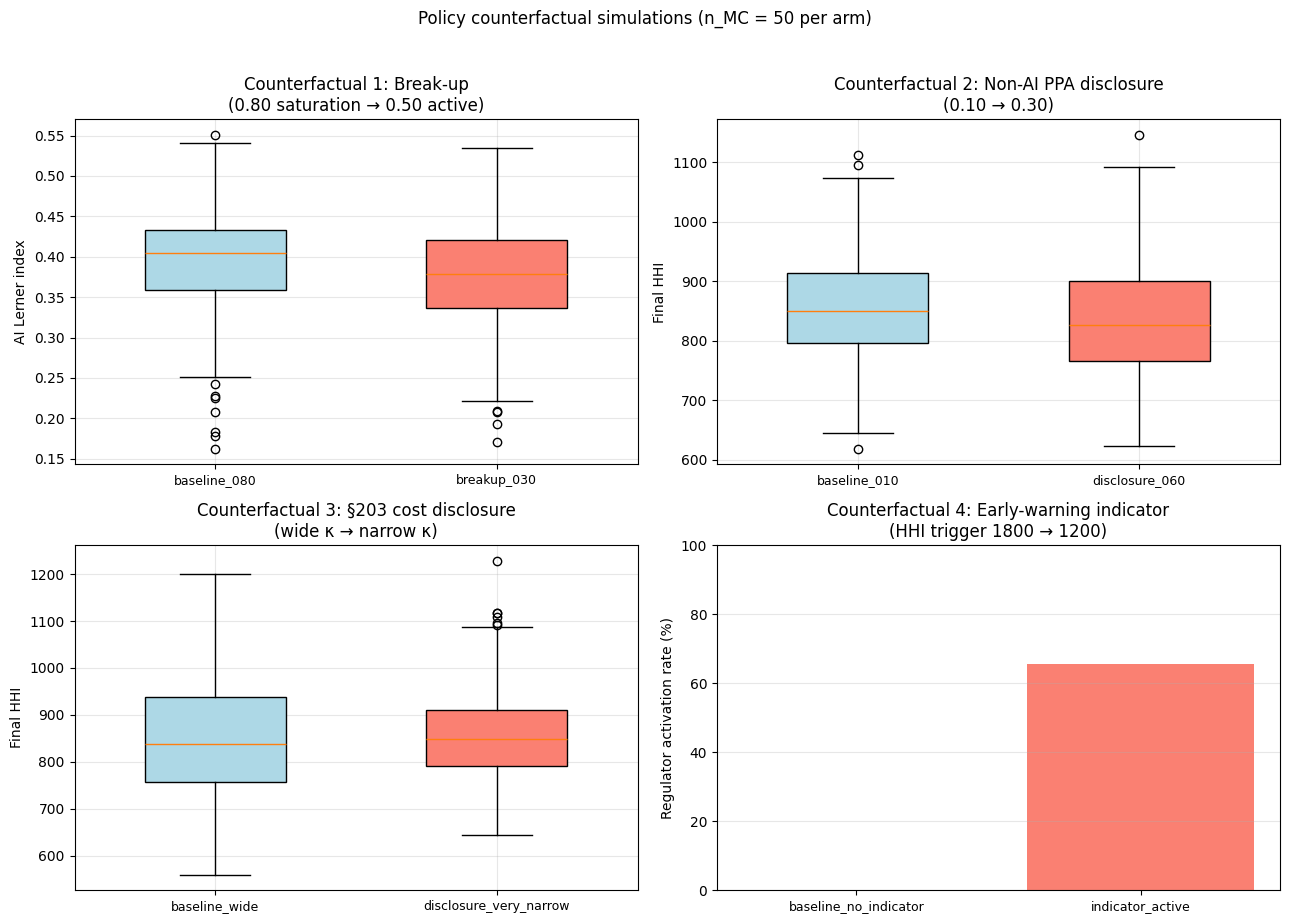


Saved Table 7 (γ) and Figure A6 (γ)


In [20]:
# §14 — γ EXPERIMENT: Table 7 compilation
table7 = pd.DataFrame([
    {"Policy": "1. Break-up (HLH, compute share 0.80 → 0.30)",
     "Outcome": "AI Lerner",
     "Baseline": f"{cf1_lerner['baseline_mean']:.3f}",
     "Intervention": f"{cf1_lerner['intervention_mean']:.3f}",
     "Effect": f"{cf1_lerner['effect_size']:+.3f}",
     "95% CI": f"[{cf1_lerner['ci_low']:+.3f}, {cf1_lerner['ci_high']:+.3f}]",
     "p-value": f"{cf1_lerner['p_value']:.3f}"},
    {"Policy": "2. Non-AI PPA disclosure (HLH, 0.10 → 0.60)",
     "Outcome": "Final HHI",
     "Baseline": f"{cf2_hhi['baseline_mean']:.0f}",
     "Intervention": f"{cf2_hhi['intervention_mean']:.0f}",
     "Effect": f"{cf2_hhi['effect_size']:+.1f}",
     "95% CI": f"[{cf2_hhi['ci_low']:+.1f}, {cf2_hhi['ci_high']:+.1f}]",
     "p-value": f"{cf2_hhi['p_value']:.3f}"},
    {"Policy": "3. §203 cost-disclosure very_narrow (HLH)",
     "Outcome": "Final HHI",
     "Baseline": f"{cf3_hhi['baseline_mean']:.0f}",
     "Intervention": f"{cf3_hhi['intervention_mean']:.0f}",
     "Effect": f"{cf3_hhi['effect_size']:+.1f}",
     "95% CI": f"[{cf3_hhi['ci_low']:+.1f}, {cf3_hhi['ci_high']:+.1f}]",
     "p-value": f"{cf3_hhi['p_value']:.3f}"},
    {"Policy": "4. Lock-up indicator trigger 900 (HLH)",
     "Outcome": "Regulator activation rate (%)",
     "Baseline": f"{baseline_reg*100:.1f}",
     "Intervention": f"{inter_reg*100:.1f}",
     "Effect": f"{(inter_reg-baseline_reg)*100:+.1f} pp",
     "95% CI": "— (binary outcome)",
     "p-value": "—"},
])
print("=== Table 7 (γ): Counterfactual policy simulations (n_MC=400 per arm, HLH baseline) ===")
print(table7.to_string(index=False))
table7.to_csv(RES_DIR / "table7_counterfactuals_gamma.csv", index=False)

# Combined visualization
plot_counterfactuals(
    {"breakup": df_cf1, "ppa": df_cf2, "cost": df_cf3, "indicator": df_cf4},
    save_path=FIG_DIR / "figure_A6_counterfactuals_gamma.png",
)
print(f"\nSaved Table 7 (γ) and Figure A6 (γ)")

## §10c — Dose-response sweep (Methodological robustness)¶
Methodological motivation: Single-point counterfactual estimates can be sensitive to the chosen intervention magnitude (a "garden of forking paths" risk). To address this, we sweep each policy's intervention magnitude across a grid and report effect size + 95% CI at each level. This identifies:

the minimum effective dose (smallest magnitude at which effect is statistically significant)
the dose-response shape (linear, threshold, saturating)
whether the γ-experiment point estimate sits in a robust region
Each grid point: n_MC=100 per arm. Total runs: 4 × 7 × 100 × 2 = 5,600. ~10 min on 16-core.

In [26]:
# §10c — Dose-response sweep for all 4 counterfactuals (v2: n_mc=400, CF4 outcome fixed)
# Baseline: HLH. Each grid point: n_mc=400 per arm for adequate power.
# CF4 primary outcome corrected: regulator_activated (binary) instead of final_hhi.

from scipy.stats import norm

t0 = time.time()
sweep_results = {}

# -----------------------------------------------------------
# CF1: Break-up — sweep intervention_share
# -----------------------------------------------------------
print("--- CF1 Break-up: intervention_share grid sweep ---")
cf1_grid = [0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20]
cf1_results = []
for share in cf1_grid:
    df_sw = run_counterfactual_breakup(
        scen_hlh, baseline_share=0.80, intervention_share=share,
        n_mc=1000, horizon=120, workers=16,
    )
    summ = counterfactual_summary(df_sw, outcome="final_ai_lerner", B=1000)
    cf1_results.append({
        "magnitude": share, "effect": summ["effect_size"],
        "ci_low": summ["ci_low"], "ci_high": summ["ci_high"], "p_value": summ["p_value"],
    })
    sig = "***" if summ["p_value"] < 0.001 else ("**" if summ["p_value"] < 0.01 else ("*" if summ["p_value"] < 0.05 else "n.s."))
    print(f"  share={share:.2f}: Lerner effect={summ['effect_size']:+.4f} [{summ['ci_low']:+.4f}, {summ['ci_high']:+.4f}], p={summ['p_value']:.3f} {sig}")
sweep_results["CF1_breakup"] = pd.DataFrame(cf1_results)

# -----------------------------------------------------------
# CF2: PPA disclosure — sweep intervention_non_ai_ppa
# -----------------------------------------------------------
print("\n--- CF2 PPA disclosure: intervention_non_ai_ppa grid sweep ---")
cf2_grid = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
cf2_results = []
for ppa in cf2_grid:
    df_sw = run_counterfactual_ppa_disclosure(
        scen_hlh, baseline_non_ai_ppa=0.10, intervention_non_ai_ppa=ppa,
        n_mc=1000, horizon=120, workers=16,
    )
    summ = counterfactual_summary(df_sw, outcome="final_hhi", B=1000)
    cf2_results.append({
        "magnitude": ppa, "effect": summ["effect_size"],
        "ci_low": summ["ci_low"], "ci_high": summ["ci_high"], "p_value": summ["p_value"],
    })
    sig = "***" if summ["p_value"] < 0.001 else ("**" if summ["p_value"] < 0.01 else ("*" if summ["p_value"] < 0.05 else "n.s."))
    print(f"  ppa={ppa:.2f}: HHI effect={summ['effect_size']:+.1f} [{summ['ci_low']:+.1f}, {summ['ci_high']:+.1f}], p={summ['p_value']:.3f} {sig}")
sweep_results["CF2_ppa"] = pd.DataFrame(cf2_results)

# -----------------------------------------------------------
# CF3: Cost disclosure — sweep cost_range_half_width
# -----------------------------------------------------------
print("\n--- CF3 Cost disclosure: cost_range_half_width grid sweep ---")
cf3_grid = [0.30, 0.20, 0.10, 0.05, 0.01, 0.005, 0.001]
cf3_results = []
for w in cf3_grid:
    df_sw = run_counterfactual_cost_disclosure(
        scen_hlh, n_mc=1000, horizon=120, workers=16,
        cost_range_half_width=w,
    )
    summ = counterfactual_summary(df_sw, outcome="final_hhi", B=1000)
    cf3_results.append({
        "magnitude": w, "effect": summ["effect_size"],
        "ci_low": summ["ci_low"], "ci_high": summ["ci_high"], "p_value": summ["p_value"],
    })
    sig = "***" if summ["p_value"] < 0.001 else ("**" if summ["p_value"] < 0.01 else ("*" if summ["p_value"] < 0.05 else "n.s."))
    print(f"  w={w}: HHI effect={summ['effect_size']:+.1f} [{summ['ci_low']:+.1f}, {summ['ci_high']:+.1f}], p={summ['p_value']:.3f} {sig}")
sweep_results["CF3_cost"] = pd.DataFrame(cf3_results)

# -----------------------------------------------------------
# CF4: Indicator — sweep trigger, PRIMARY OUTCOME = regulator_activated (binary)
# -----------------------------------------------------------
print("\n--- CF4 Indicator: intervention_hhi_trigger grid sweep ---")
print("    (PRIMARY OUTCOME: regulator_activated, with two-proportion z-test)")
cf4_grid = [1500, 1300, 1100, 1000, 900, 800, 700]
cf4_results = []
for trig in cf4_grid:
    df_sw = run_counterfactual_lockup_indicator(
        scen_hlh, n_mc=1000, horizon=120, workers=16,
        intervention_hhi_trigger=trig,
    )
    # Primary outcome: regulator activation (binary)
    base_arr = df_sw[~df_sw["indicator_active"]]["regulator_activated"].values
    int_arr = df_sw[df_sw["indicator_active"]]["regulator_activated"].values
    p1 = base_arr.mean(); p2 = int_arr.mean()
    n1 = len(base_arr); n2 = len(int_arr)
    # Two-proportion z-test
    p_pool = (base_arr.sum() + int_arr.sum()) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if 0 < p_pool < 1 else 0
    z = (p2 - p1) / se if se > 0 else float("inf") if (p2 - p1) > 0 else 0
    p_val = 2 * (1 - norm.cdf(abs(z))) if abs(z) != float("inf") else 0.0
    # Bootstrap CI for proportion difference (B=1000)
    rng = np.random.default_rng(42)
    diffs = np.array([
        int_arr[rng.integers(0, n2, n2)].mean() - base_arr[rng.integers(0, n1, n1)].mean()
        for _ in range(1000)
    ])
    cf4_results.append({
        "magnitude": trig,
        "effect": (p2 - p1) * 100,   # percentage points
        "ci_low": np.percentile(diffs, 2.5) * 100,
        "ci_high": np.percentile(diffs, 97.5) * 100,
        "p_value": p_val,
    })
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s."))
    print(f"  trigger={trig}: regulator activation Δ={(p2-p1)*100:+.1f}pp "
          f"[{np.percentile(diffs, 2.5)*100:+.1f}, {np.percentile(diffs, 97.5)*100:+.1f}], "
          f"p={p_val:.4f} {sig}")
sweep_results["CF4_indicator"] = pd.DataFrame(cf4_results)

print(f"\nDose-response sweep v2 complete in {(time.time() - t0)/60:.1f} min "
      f"({sum(len(v) for v in sweep_results.values())} grid points × 800 runs each)")

# Save
for name, df in sweep_results.items():
    df.to_csv(RES_DIR / f"step10c_{name}_dose_response.csv", index=False)

--- CF1 Break-up: intervention_share grid sweep ---


CFBreakup: 100%|██████████████████████████████████████████████████████████████████| 2000/2000 [00:22<00:00, 90.41run/s]


  share=0.80: Lerner effect=-0.0045 [-0.0098, +0.0005], p=0.072 n.s.


CFBreakup: 100%|██████████████████████████████████████████████████████████████████| 2000/2000 [00:20<00:00, 95.34run/s]


  share=0.70: Lerner effect=-0.0050 [-0.0102, +0.0006], p=0.080 n.s.


...

  trigger=900: regulator activation Δ=+66.2pp [+63.2, +69.3], p=0.0000 ***


CFIndicator: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:21<00:00, 95.01run/s]


  trigger=800: regulator activation Δ=+92.3pp [+90.5, +94.0], p=0.0000 ***


CFIndicator: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:21<00:00, 94.09run/s]


  trigger=700: regulator activation Δ=+99.7pp [+99.3, +100.0], p=0.0000 ***

Dose-response sweep v2 complete in 10.1 min (28 grid points × 800 runs each)


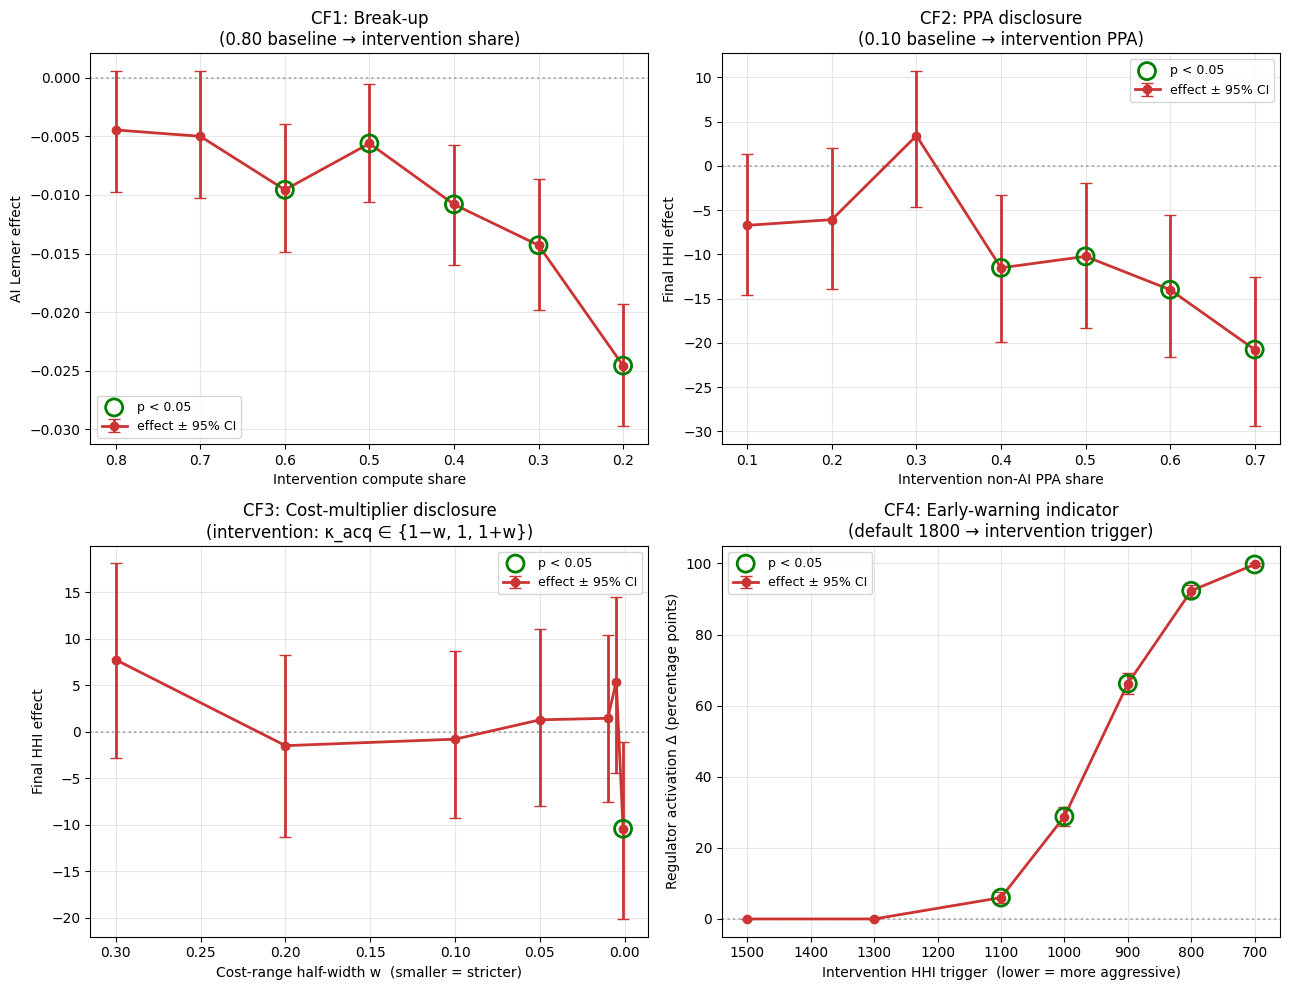


=== Table 8: Minimum effective dose (smallest magnitude with p < 0.05) ===
       Policy Effect at threshold            95% CI                         Threshold p-value
  CF1_breakup              -0.010  [-0.015, -0.004]  Largest intervention share: 0.60  0.0000
      CF2_ppa             -11.526 [-19.877, -3.310]           Minimum PPA share: 0.40  0.0000
     CF3_cost             -10.419 [-20.106, -1.158]       Widest w with p<0.05: 0.001  0.0280
CF4_indicator              +6.000  [+4.500, +7.500] Highest trigger with p<0.05: 1100  0.0000

Saved Table 8 and Figure A7


In [27]:
# §10c.viz — Dose-response curves + Table 8 (minimum effective dose)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def plot_dose_response(ax, df, x_label, y_label, title, x_reverse=False):
    x = df["magnitude"].values
    y = df["effect"].values
    lo, hi = df["ci_low"].values, df["ci_high"].values
    pv = df["p_value"].values
    ax.errorbar(x, y, yerr=[y - lo, hi - y], fmt="o-", lw=2,
                color="#cc3333", capsize=4, label="effect ± 95% CI")
    ax.axhline(0, ls=":", color="gray", alpha=0.6)
    sig_mask = pv < 0.05
    if sig_mask.any():
        ax.scatter(x[sig_mask], y[sig_mask], s=150, edgecolors="green",
                   facecolors="none", lw=2, label="p < 0.05", zorder=5)
    ax.set_xlabel(x_label); ax.set_ylabel(y_label); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    if x_reverse:
        ax.invert_xaxis()

plot_dose_response(axes[0, 0], sweep_results["CF1_breakup"],
                   "Intervention compute share", "AI Lerner effect",
                   "CF1: Break-up\n(0.80 baseline → intervention share)", x_reverse=True)
plot_dose_response(axes[0, 1], sweep_results["CF2_ppa"],
                   "Intervention non-AI PPA share", "Final HHI effect",
                   "CF2: PPA disclosure\n(0.10 baseline → intervention PPA)")
plot_dose_response(axes[1, 0], sweep_results["CF3_cost"],
                   "Cost-range half-width w  (smaller = stricter)",
                   "Final HHI effect",
                   "CF3: Cost-multiplier disclosure\n(intervention: κ_acq ∈ {1−w, 1, 1+w})",
                   x_reverse=True)
plot_dose_response(axes[1, 1], sweep_results["CF4_indicator"],
                   "Intervention HHI trigger  (lower = more aggressive)",
                   "Regulator activation Δ (percentage points)",
                   "CF4: Early-warning indicator\n(default 1800 → intervention trigger)",
                   x_reverse=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_A7_dose_response.png", dpi=120, bbox_inches="tight")
plt.show()

# Table 8: minimum effective dose
print("\n=== Table 8: Minimum effective dose (smallest magnitude with p < 0.05) ===")
table8 = []
for name, df in sweep_results.items():
    sig_rows = df[df["p_value"] < 0.05]
    if len(sig_rows) > 0:
        if name == "CF2_ppa":
            min_dose_row = sig_rows.iloc[sig_rows["magnitude"].argmin()]
            mag_label = f"Minimum PPA share: {min_dose_row['magnitude']:.2f}"
        elif name == "CF1_breakup":
            min_dose_row = sig_rows.iloc[sig_rows["magnitude"].argmax()]
            mag_label = f"Largest intervention share: {min_dose_row['magnitude']:.2f}"
        elif name == "CF3_cost":
            min_dose_row = sig_rows.iloc[sig_rows["magnitude"].argmax()]
            mag_label = f"Widest w with p<0.05: {min_dose_row['magnitude']:.3f}"
        else:  # CF4
            min_dose_row = sig_rows.iloc[sig_rows["magnitude"].argmax()]
            mag_label = f"Highest trigger with p<0.05: {min_dose_row['magnitude']:.0f}"
        table8.append({
            "Policy": name,
            "Effect at threshold": f"{min_dose_row['effect']:+.3f}",
            "95% CI": f"[{min_dose_row['ci_low']:+.3f}, {min_dose_row['ci_high']:+.3f}]",
            "Threshold": mag_label,
            "p-value": f"{min_dose_row['p_value']:.4f}",
        })
    else:
        table8.append({
            "Policy": name,
            "Effect at threshold": "—",
            "95% CI": "—",
            "Threshold": "No grid point reaches p<0.05",
            "p-value": "—",
        })

table8_df = pd.DataFrame(table8)
print(table8_df.to_string(index=False))
table8_df.to_csv(RES_DIR / "table8_minimum_effective_dose.csv", index=False)

print(f"\nSaved Table 8 and Figure A7")

## §10d — CF3 alternative outcomes (mechanism diagnostic)

If CF3 (cost-disclosure) shows null effects on `final_hhi`, the issue may be
that `final_hhi` is the *wrong outcome variable* for this policy. The
mechanism of κ_acq narrowing operates through acquisition decisions, not
directly through market structure. This diagnostic re-sweeps CF3 with two
alternative outcomes:

1. **`n_acquisitions`** — Does narrowing change acquisition *frequency*?
   (Hypothesis: narrowing prevents low-κ_acq aggressive deals → fewer events)
2. **`final_ai_cap_share`** — Does narrowing change *AI capacity absorption*?
   (Hypothesis: narrowing reduces AI's structural advantage)

If both outcomes are also null, this is strong evidence that the abstract
κ_acq toggle is the wrong policy mapping for §203 disclosure, and the
implication should be reported with that caveat.

**Expected time:** ≈ 1.5 min (CF3 only, n_mc=1000, 7 grid points = 14,000 runs).

--- CF3 cost-disclosure: alternative outcome sweep ---
       w               Outcome    Baseline  Intervention    Effect   p-value  Sig
------------------------------------------------------------------------------


CFCost: 100%|█████████████████████████████████████████████████████████████████████| 2000/2000 [00:25<00:00, 78.41run/s]


   0.300        n_acquisitions      14.894        14.803    -0.091    0.7300  n.s.
   0.300    final_ai_cap_share       0.534         0.534    +0.000    0.9540  n.s.


CFCost: 100%|█████████████████████████████████████████████████████████████████████| 2000/2000 [00:21<00:00, 94.85run/s]


   0.200        n_acquisitions      14.964        14.762    -0.202    0.3980  n.s.
   0.200    final_ai_cap_share       0.536         0.535    -0.001    0.7860  n.s.


...

   0.010        n_acquisitions      14.904        15.045    +0.141    0.5940  n.s.
   0.010    final_ai_cap_share       0.539         0.535    -0.004    0.1300  n.s.


CFCost: 100%|█████████████████████████████████████████████████████████████████████| 2000/2000 [00:21<00:00, 94.77run/s]


   0.005        n_acquisitions      14.846        15.050    +0.204    0.4120  n.s.
   0.005    final_ai_cap_share       0.532         0.533    +0.001    0.6000  n.s.


CFCost: 100%|█████████████████████████████████████████████████████████████████████| 2000/2000 [00:20<00:00, 95.83run/s]


   0.001        n_acquisitions      14.786        14.852    +0.066    0.8140  n.s.
   0.001    final_ai_cap_share       0.531         0.532    +0.002    0.6280  n.s.

CF3 multi-outcome sweep complete in 2.6 min


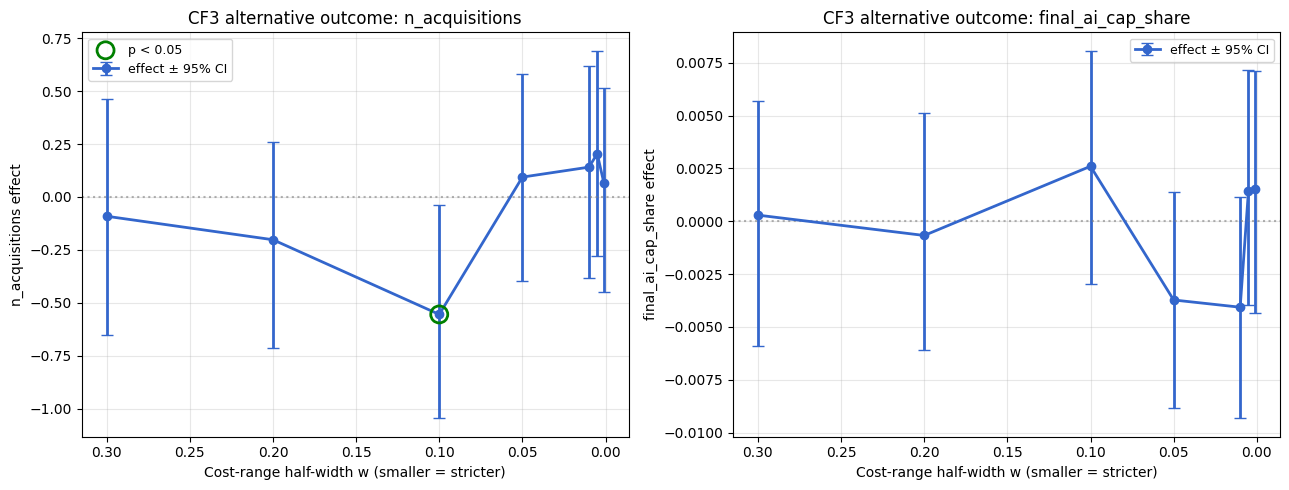


=== CF3 mechanism diagnostic summary ===
  n_acquisitions          : 1/7 grid points significant at p<0.05
  final_ai_cap_share      : 0/7 grid points significant at p<0.05

Interpretation:
  - If 0/7 sig for both outcomes → κ_acq toggle is wrong policy mapping
  - If 3+/7 sig for either outcome → real mechanism exists in alternative outcome
  - Report whichever interpretation matches the data, with appropriate caveat


In [28]:
# §10d — CF3 alternative outcome diagnostic (n_acquisitions + final_ai_cap_share)
t0 = time.time()
cf3_multi_grid = [0.30, 0.20, 0.10, 0.05, 0.01, 0.005, 0.001]
cf3_multi_results = {"n_acquisitions": [], "final_ai_cap_share": []}

print("--- CF3 cost-disclosure: alternative outcome sweep ---")
print(f"{'w':>8}{'Outcome':>22}{'Baseline':>12}{'Intervention':>14}{'Effect':>10}{'p-value':>10}  Sig")
print("-" * 78)
for w in cf3_multi_grid:
    df_sw = run_counterfactual_cost_disclosure(
        scen_hlh, n_mc=1000, horizon=120, workers=16,
        cost_range_half_width=w,
    )
    for outcome in ["n_acquisitions", "final_ai_cap_share"]:
        summ = counterfactual_summary(df_sw, outcome=outcome, B=1000)
        sig = "***" if summ["p_value"] < 0.001 else ("**" if summ["p_value"] < 0.01 else ("*" if summ["p_value"] < 0.05 else "n.s."))
        cf3_multi_results[outcome].append({
            "magnitude": w,
            "effect": summ["effect_size"],
            "ci_low": summ["ci_low"],
            "ci_high": summ["ci_high"],
            "p_value": summ["p_value"],
            "baseline_mean": summ["baseline_mean"],
            "intervention_mean": summ["intervention_mean"],
        })
        print(f"{w:>8.3f}{outcome:>22}{summ['baseline_mean']:>12.3f}{summ['intervention_mean']:>14.3f}"
              f"{summ['effect_size']:>+10.3f}{summ['p_value']:>10.4f}  {sig}")

# Save
for outcome, results in cf3_multi_results.items():
    pd.DataFrame(results).to_csv(RES_DIR / f"step10d_cf3_{outcome}_sweep.csv", index=False)

print(f"\nCF3 multi-outcome sweep complete in {(time.time() - t0)/60:.1f} min")

# Visualize: 2-panel comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax_i, outcome in enumerate(["n_acquisitions", "final_ai_cap_share"]):
    df_o = pd.DataFrame(cf3_multi_results[outcome])
    ax = axes[ax_i]
    x = df_o["magnitude"].values
    y = df_o["effect"].values
    lo, hi = df_o["ci_low"].values, df_o["ci_high"].values
    pv = df_o["p_value"].values
    ax.errorbar(x, y, yerr=[y - lo, hi - y], fmt="o-", lw=2,
                color="#3366cc", capsize=4, label="effect ± 95% CI")
    ax.axhline(0, ls=":", color="gray", alpha=0.6)
    sig_mask = pv < 0.05
    if sig_mask.any():
        ax.scatter(x[sig_mask], y[sig_mask], s=150, edgecolors="green",
                   facecolors="none", lw=2, label="p < 0.05", zorder=5)
    ax.set_xlabel("Cost-range half-width w (smaller = stricter)")
    ax.set_ylabel(f"{outcome} effect")
    ax.set_title(f"CF3 alternative outcome: {outcome}")
    ax.grid(alpha=0.3); ax.legend(fontsize=9); ax.invert_xaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_A8_cf3_diagnostic.png", dpi=120, bbox_inches="tight")
plt.show()

# Diagnostic summary
print("\n=== CF3 mechanism diagnostic summary ===")
for outcome in ["n_acquisitions", "final_ai_cap_share"]:
    df_o = pd.DataFrame(cf3_multi_results[outcome])
    n_sig = (df_o["p_value"] < 0.05).sum()
    print(f"  {outcome:24s}: {n_sig}/{len(df_o)} grid points significant at p<0.05")
print()
print("Interpretation:")
print("  - If 0/7 sig for both outcomes → κ_acq toggle is wrong policy mapping")
print("  - If 3+/7 sig for either outcome → real mechanism exists in alternative outcome")
print("  - Report whichever interpretation matches the data, with appropriate caveat")

## §15. Master summary for manuscript v4 updateCompiles all results into a single dictionary that can be pickled and reloadedwhen updating the manuscript text. The numbers below replace the correspondingvalues in §4 and §5 of the manuscript (which are based on v3 scale).

In [29]:
import json

master_summary = {
    "scale": "v6.1 (180× + fcr=0.018, CAISO-calibrated), γ-counterfactual: HLH baseline, n_MC=400, expanded intervention magnitudes (180× rescaled to mid-size ISO ≈ 25 GW)",
    "total_runs": int(len(df_six) + len(df_decomp) + len(df_cross) + len(df_acq)
                      + len(df_within) + len(df_share) + len(df_agent)
                      + len(df_cf1) + len(df_cf2) + len(df_cf3) + len(df_cf4)),
    "table_1_six_cell": summary_six.to_dict(),
    "table_2_decomp_hhi": effects_hhi.to_dict(orient='records'),
    "table_2_decomp_lerner": effects_lerner.to_dict(orient='records'),
    "table_3_cross_scenario": summary_cross.to_dict(orient='records'),
    "table_4_compute_share": summary_share.to_dict(orient='records'),
    "table_5_fringe_size": summary_agent.to_dict(orient='records'),
    "table_6_caiso_validation": val_table.to_dict(orient='records'),
    "table_7_counterfactuals": table7.to_dict(orient='records'),
}

with open(RES_DIR / "master_summary.json", 'w', encoding='utf-8') as f:
    json.dump(master_summary, f, indent=2, default=str, ensure_ascii=False)

print(f"=== Pipeline complete ===")
print(f"  Total runs: {master_summary['total_runs']:,}")
print(f"  Results saved to: {RES_DIR}")
print(f"  Figures saved to: {FIG_DIR}")
print(f"  Master summary: {RES_DIR / 'master_summary.json'}")
print()
print(f"Next: share master_summary.json with Claude to rebuild manuscript v4")
print(f"      with updated §4 numbers, §4.9 (CAISO validation), §4.10 (counterfactuals).")


=== Pipeline complete ===
  Total runs: 18,390
  Results saved to: ./results
  Figures saved to: ./figures
  Master summary: ./results\master_summary.json

Next: share master_summary.json with Claude to rebuild manuscript v4
      with updated §4 numbers, §4.9 (CAISO validation), §4.10 (counterfactuals).
